In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import sys
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
missed=pd.read_csv('/content/drive/MyDrive/Datasets/shots_dataSet/missed_shots.csv')
goal=pd.read_csv('/content/drive/MyDrive/Datasets/shots_dataSet/goal_shots.csv')

In [ ]:
goal['golo']=1
missed['golo']=0

In [ ]:
dataset = pd.concat([goal, missed])
dataset.reset_index(inplace=True)
dataset

,index,Unnamed: 0,id,event_id,type_id,event_name,period_id,min,sec,team_id,...,Close high,35+ right,Close right and high,233,Keeper Saved,314,Close left and high,Out of box-right,Out of box-deep right,35+ left
0,0,0,2267410127,304,16,Goal,1,38,16,6644,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0,2230821285,98,16,Goal,1,10,36,255,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1,2230835833,364,16,Goal,1,42,47,255,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2,2230854433,460,16,Goal,2,54,47,255,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,3,2230861893,628,16,Goal,2,73,51,255,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3511,2788,2,2226982257,376,13,Miss,1,35,15,255,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3512,2789,3,2226983125,415,13,Miss,1,39,1,255,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3513,2790,4,2226984017,469,13,Miss,1,43,18,255,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3514,2791,5,2226984555,352,13,Miss,1,45,45,666,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
dataset = dataset.drop(columns = ['Unnamed: 0',
 'id',
 'event_id',
 'type_id',
 'event_name',
 'period_id',
 'min',
 'sec',
 'team_id',
 'outcome',
 'timestamp',
 'last_modified',
 'version',
 'player_id',
 'keypass',
 'competition_id',
 'game_id',
 'home_team_id',
 'home_team_name',
 'away_team_id',
 'away_team_name',
 'competition_name',
 'season_id',
 'Related event ID',
 '2nd related event ID',
 '374',
 '375',
 '395',
 '396',
 '280',
 '281',
 '282',
 '328',
 '353',
 '390',
 '273',
 '388',
 '254',
 '300',
 '343',
 '274',
 '275',
 '362',
 '359',
 '389',
 '276',
 '391',
 '233',
 '314',])

In [ ]:
df_treino = pd.DataFrame()

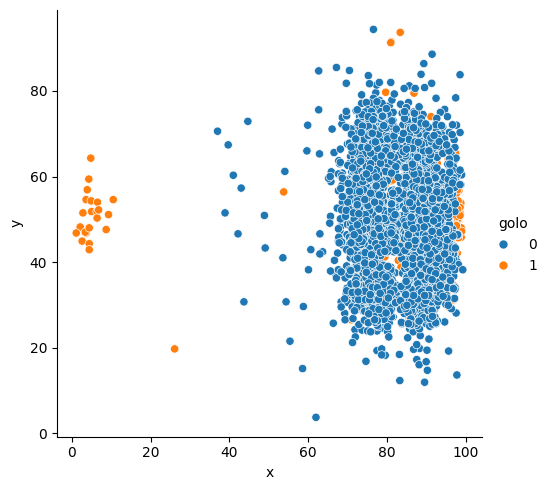

In [ ]:
# Analisamos o diagrama de dispersão das varáveis x e y.
# Verifica-se a existência de alguns valores para x muito baixos que resultaram em golo.
# Vamos fazer drop a essas linhas comparando o seu efeito com nada fazer.

df = dataset[['x','y','golo']]
sns.relplot(x='x', y='y', hue='golo', data=df)

In [ ]:
df_treino = dataset[['x','y','golo']]

In [ ]:
from sklearn.preprocessing import MinMaxScaler

sklearn_min_max = MinMaxScaler()
df_treino['x'] = sklearn_min_max.fit_transform(df_treino[['x']])
df_treino['y'] = sklearn_min_max.fit_transform(df_treino[['y']])

<ipython-input-10-c4eedf9140d8>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_treino['x'] = sklearn_min_max.fit_transform(df_treino[['x']])
<ipython-input-10-c4eedf9140d8>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_treino['y'] = sklearn_min_max.fit_transform(df_treino[['y']])


In [ ]:
X = df_treino[['x','y']]

y = df_treino['golo'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print ('Conjunto de treino: %d linhas\nConjunto de teste %d linhas' % (X_train.shape[0], X_test.shape[0]))

Conjunto de treino: 2812 linhas
Conjunto de teste 704 linhas


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)
probability = model.predict_proba(X_test)

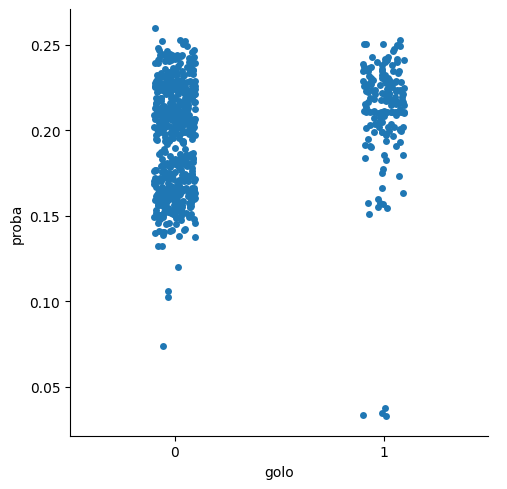

In [ ]:
goal_probability = list()
for res in probability:
  goal_probability.append(res[1])
data = pd.DataFrame(zip(y_test,goal_probability), columns=['golo','proba'])

sns.catplot(x='golo', y='proba',data=data)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86       536
           1       0.00      0.00      0.00       168

    accuracy                           0.76       704
   macro avg       0.38      0.50      0.43       704
weighted avg       0.58      0.76      0.66       704



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


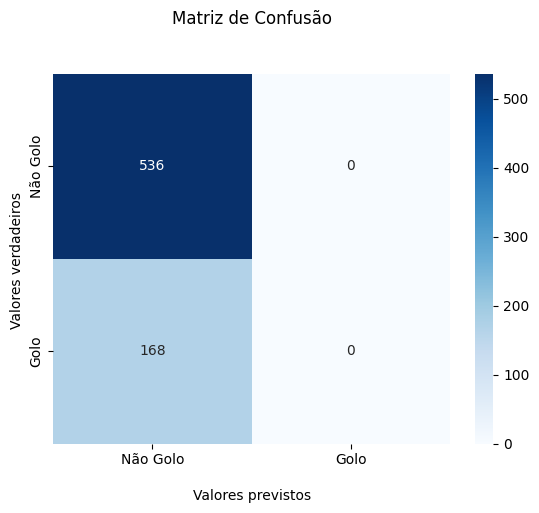

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')

ax.set_title('Matriz de Confusão\n\n');
ax.set_xlabel('\nValores previstos')
ax.set_ylabel('Valores verdadeiros ');

ax.xaxis.set_ticklabels(['Não Golo','Golo'])
ax.yaxis.set_ticklabels(['Não Golo','Golo'])

plt.show()

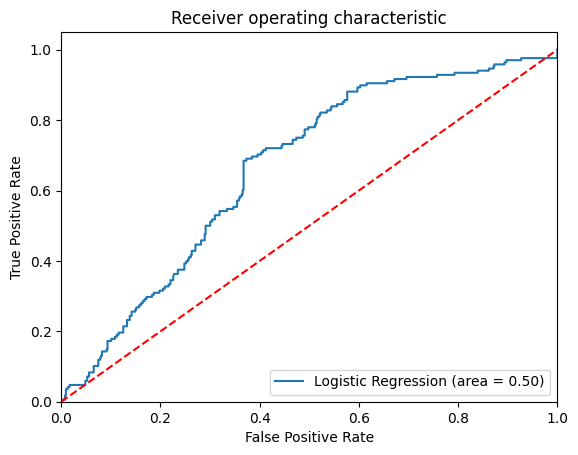

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

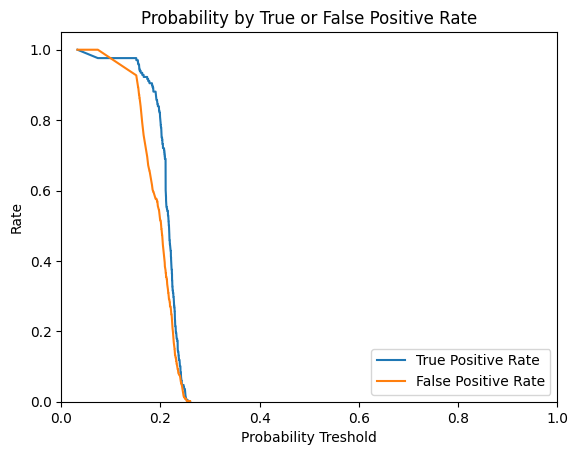

In [ ]:
plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Probability Treshold')
plt.ylabel('Rate')
plt.title('Probability by True or False Positive Rate')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Vamos fazer drop às linhas nas quais os valores de x são inferiores a 50 e verificar o seu efeito no modelo

In [ ]:
dataset_filtered = dataset[dataset['x']>=50]

In [ ]:
df_treino = dataset_filtered[['x','y','golo']]
df_treino_safe = df_treino.copy()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

sklearn_min_max = MinMaxScaler()
df_treino['x'] = sklearn_min_max.fit_transform(df_treino[['x']])
df_treino['y'] = sklearn_min_max.fit_transform(df_treino[['y']])

<ipython-input-21-c4eedf9140d8>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_treino['x'] = sklearn_min_max.fit_transform(df_treino[['x']])
<ipython-input-21-c4eedf9140d8>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_treino['y'] = sklearn_min_max.fit_transform(df_treino[['y']])


In [ ]:
X = df_treino[['x','y']]

y = df_treino['golo'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print ('Conjunto de treino: %d linhas\nConjunto de teste %d linhas' % (X_train.shape[0], X_test.shape[0]))

Conjunto de treino: 2785 linhas
Conjunto de teste 697 linhas


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)
probability = model.predict_proba(X_test)

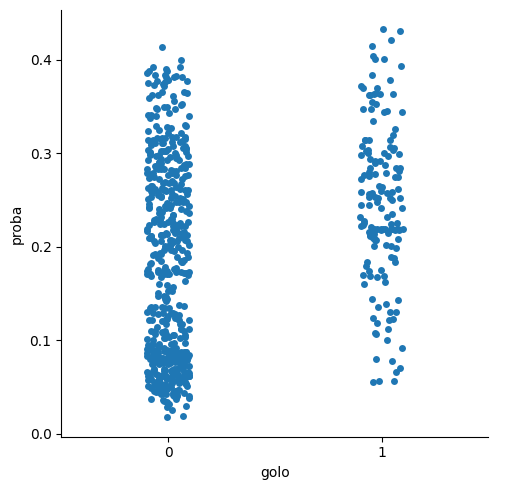

In [ ]:
goal_probability = list()
for res in probability:
  goal_probability.append(res[1])
data = pd.DataFrame(zip(y_test,goal_probability), columns=['golo','proba'])

sns.catplot(x='golo', y='proba',data=data)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      1.00      0.87       541
           1       0.00      0.00      0.00       156

    accuracy                           0.78       697
   macro avg       0.39      0.50      0.44       697
weighted avg       0.60      0.78      0.68       697



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


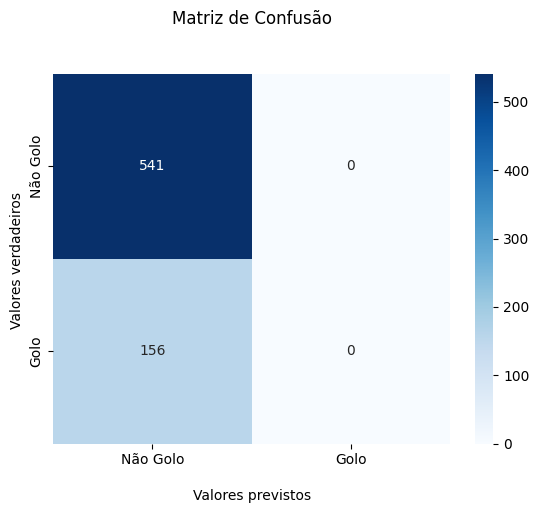

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')

ax.set_title('Matriz de Confusão\n\n');
ax.set_xlabel('\nValores previstos')
ax.set_ylabel('Valores verdadeiros ');

ax.xaxis.set_ticklabels(['Não Golo','Golo'])
ax.yaxis.set_ticklabels(['Não Golo','Golo'])

plt.show()

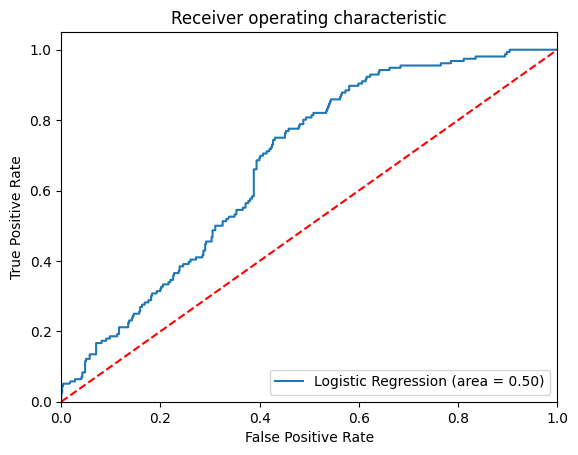

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

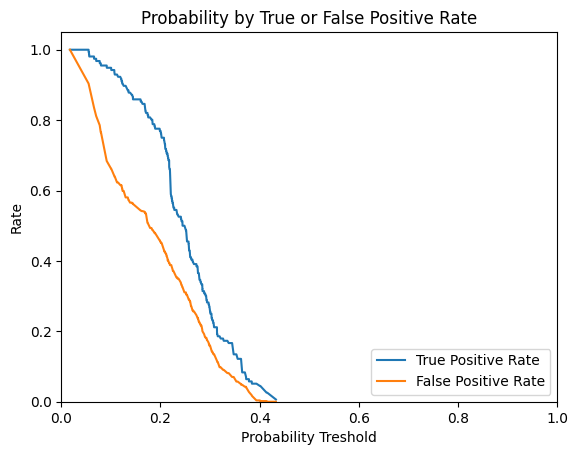

In [ ]:
plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Probability Treshold')
plt.ylabel('Rate')
plt.title('Probability by True or False Positive Rate')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Conseguimos, com este filtro, aumentar dois pontos nas quatro métricas.
# Vamos, em seguida, introduzir duas variáveis distância e ângulo para substituir x e y

In [ ]:
df = dataset_filtered.copy()

df["X"] = (100 - df['x']) * 105/100 # Inverte a abcissa do remate e calcula o valor proporcional num campo de 105 metros de comprimento
df["Y"] = df['y'] * 68/100           # Calcula o valor proporcional da ordenada do remate num campo de 68 metros de largura
df["C"] = abs(df['y'] - 50) * 68/100 # Calcula o valor da proporcional num campo de 68 metros de largura da distância da ordenada do remate e a ordenada central no campo

#calcular a distancia e o ângulo de remate
df["Distance"] = np.sqrt(df["X"]**2 + df["C"]**2)
df["Angle_new"] = np.where(np.pi/2 - np.arctan((df["C"]-7.32/2)/df["X"]) - np.arctan(df["X"]/(df["C"]+7.32/2)) > 0,
                           np.pi/2 - np.arctan((df["C"]-7.32/2)/df["X"]) - np.arctan(df["X"]/(df["C"]+7.32/2)),
                           np.pi/2 - np.arctan((df["C"]-7.32/2)/df["X"]) - np.arctan(df["X"]/(df["C"]+7.32/2)) + np.pi)

In [ ]:
df_treino = pd.DataFrame()
df_treino['Distance'] = df['Distance']
df_treino['Angle_new'] = df['Angle_new']
df_treino['golo'] = df['golo']
df_treino

,Distance,Angle_new,golo
0,3.705698,1.558284,1
1,11.523044,0.475607,1
2,15.156071,0.467287,1
3,17.708799,0.368899,1
4,15.844329,0.427851,1
...,...,...,...
3511,9.404578,0.710416,0
3512,12.492402,0.534976,0
3513,31.807091,0.225531,0
3514,31.060925,0.210903,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

sklearn_min_max = MinMaxScaler()
df_treino['Distance'] = sklearn_min_max.fit_transform(df_treino[['Distance']])
df_treino['Angle_new'] = sklearn_min_max.fit_transform(df_treino[['Angle_new']])

In [ ]:
X = df_treino[['Distance','Angle_new']]

y = df_treino['golo'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print ('Conjunto de treino: %d linhas\nConjunto de teste %d linhas' % (X_train.shape[0], X_test.shape[0]))

Conjunto de treino: 2785 linhas
Conjunto de teste 697 linhas


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
probability = model.predict_proba(X_test)
probability

array([[0.95315271, 0.04684729],
       [0.81782945, 0.18217055],
       [0.44410205, 0.55589795],
       ...,
       [0.93572499, 0.06427501],
       [0.81546378, 0.18453622],
       [0.9568296 , 0.0431704 ]])

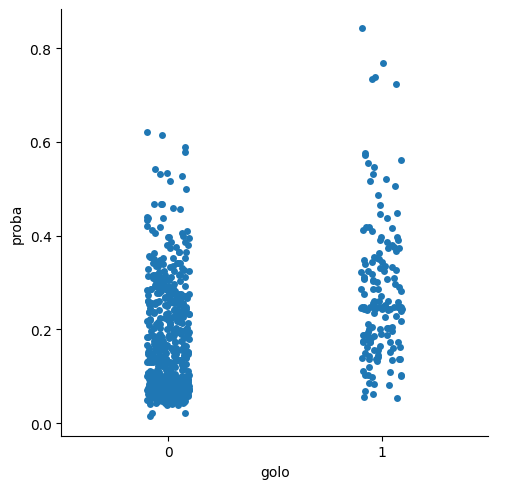

In [ ]:
goal_probability = list()
for res in probability:
  goal_probability.append(res[1])
data = pd.DataFrame(zip(y_test,goal_probability), columns=['golo','proba'])

sns.catplot(x='golo', y='proba',data=data)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.98      0.88       541
           1       0.61      0.09      0.16       156

    accuracy                           0.78       697
   macro avg       0.70      0.54      0.52       697
weighted avg       0.75      0.78      0.71       697



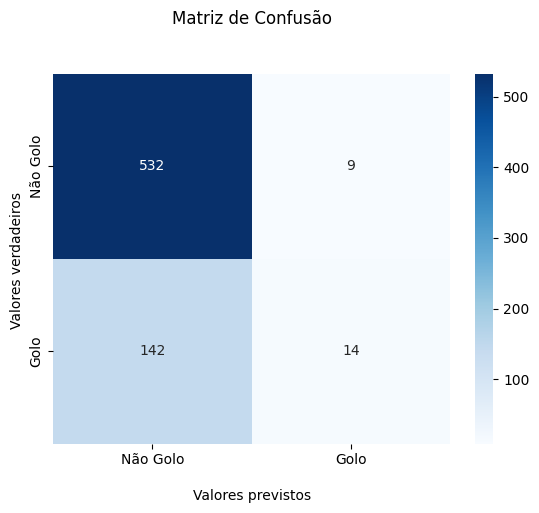

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')

ax.set_title('Matriz de Confusão\n\n');
ax.set_xlabel('\nValores previstos')
ax.set_ylabel('Valores verdadeiros ');

ax.xaxis.set_ticklabels(['Não Golo','Golo'])
ax.yaxis.set_ticklabels(['Não Golo','Golo'])

plt.show()

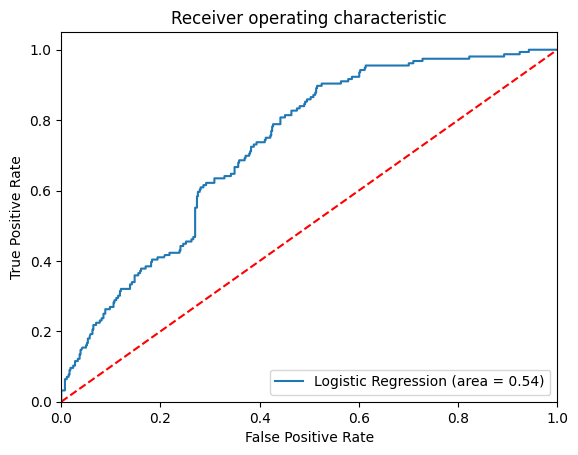

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

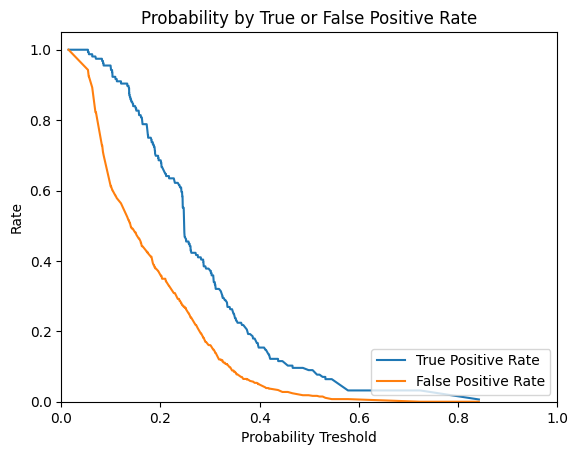

In [ ]:
plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Probability Treshold')
plt.ylabel('Rate')
plt.title('Probability by True or False Positive Rate')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Vamos verificar a correlação existente entre as novas e as variáveis x e y

In [ ]:
dataset_corr = df[['x','y','Distance','Angle_new','golo']]
dataset_corr.corr()

,x,y,Distance,Angle_new,golo
x,1.000000,-0.039498,-0.955426,0.663052,0.274165
y,-0.039498,1.000000,0.054158,-0.038336,0.002296
Distance,-0.955426,0.054158,1.000000,-0.778452,-0.311871
Angle_new,0.663052,-0.038336,-0.778452,1.000000,0.348185
golo,0.274165,0.002296,-0.311871,0.348185,1.000000


A variável x é muito correlacionada com distance e angle_new.
A variável y não se correlaciona com golo.
Vamos verificar se traz vantagem em manter as variáveis x e y.

<Axes: >

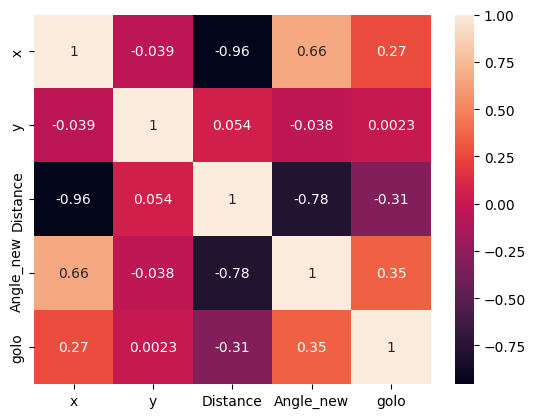

In [ ]:
sns.heatmap(dataset_corr.corr(), annot=True)

In [ ]:
df_treino = pd.DataFrame()
df_treino['x'] = df['x']
df_treino['y'] = df['y']
df_treino['Distance'] = df['Distance']
df_treino['Angle_new'] = df['Angle_new']
df_treino['golo'] = df['golo']
df_treino

,x,y,Distance,Angle_new,golo
0,96.5,49.3,3.705698,1.558284,1
1,92.0,61.6,11.523044,0.475607,1
2,85.8,46.0,15.156071,0.467287,1
3,84.9,38.4,17.708799,0.368899,1
4,85.9,58.3,15.844329,0.427851,1
...,...,...,...,...,...
3511,91.6,54.8,9.404578,0.710416,0
3512,89.0,57.0,12.492402,0.534976,0
3513,70.2,58.4,31.807091,0.225531,0
3514,73.5,70.3,31.060925,0.210903,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

sklearn_min_max = MinMaxScaler()
df_treino['x'] = sklearn_min_max.fit_transform(df_treino[['x']])
df_treino['y'] = sklearn_min_max.fit_transform(df_treino[['y']])
df_treino['Distance'] = sklearn_min_max.fit_transform(df_treino[['Distance']])
df_treino['Angle_new'] = sklearn_min_max.fit_transform(df_treino[['Angle_new']])

In [ ]:
X = df_treino[['x','y','Distance','Angle_new']]

y = df_treino['golo'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print ('Conjunto de treino: %d linhas\nConjunto de teste %d linhas' % (X_train.shape[0], X_test.shape[0]))

Conjunto de treino: 2785 linhas
Conjunto de teste 697 linhas


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
probability = model.predict_proba(X_test)
probability

array([[0.95560399, 0.04439601],
       [0.78997181, 0.21002819],
       [0.43101736, 0.56898264],
       ...,
       [0.94415574, 0.05584426],
       [0.81965448, 0.18034552],
       [0.94670011, 0.05329989]])

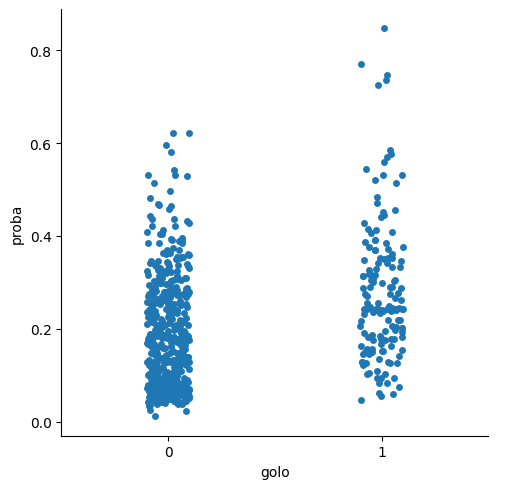

In [ ]:
goal_probability = list()
for res in probability:
  goal_probability.append(res[1])
data = pd.DataFrame(zip(y_test,goal_probability), columns=['golo','proba'])

sns.catplot(x='golo', y='proba',data=data)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.98      0.88       541
           1       0.61      0.09      0.16       156

    accuracy                           0.78       697
   macro avg       0.70      0.54      0.52       697
weighted avg       0.75      0.78      0.71       697



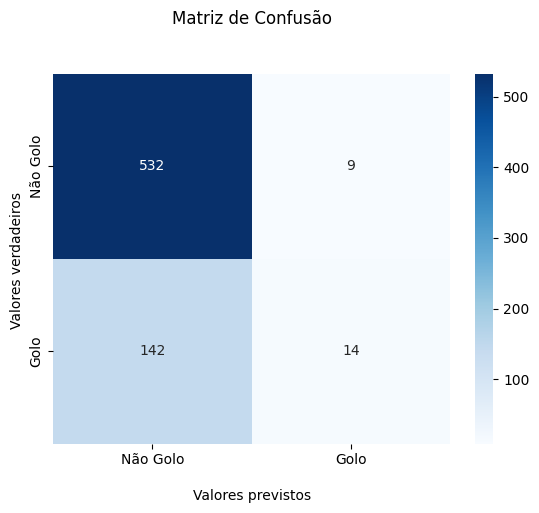

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')

ax.set_title('Matriz de Confusão\n\n');
ax.set_xlabel('\nValores previstos')
ax.set_ylabel('Valores verdadeiros ');

ax.xaxis.set_ticklabels(['Não Golo','Golo'])
ax.yaxis.set_ticklabels(['Não Golo','Golo'])

plt.show()

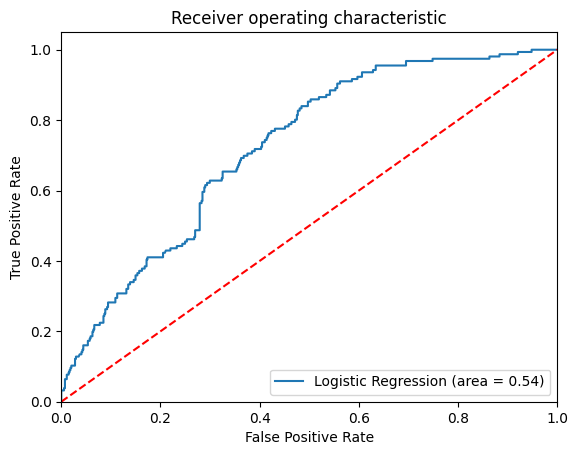

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

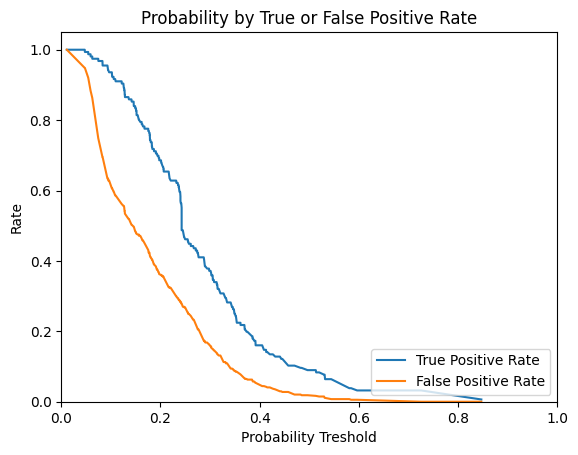

In [ ]:
plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Probability Treshold')
plt.ylabel('Rate')
plt.title('Probability by True or False Positive Rate')
plt.legend(loc="lower right")
plt.show()

Vamos manter apenas as variáveis Distance e Angle.
Vamos introduzir as variáveis categóricas.

In [ ]:
df = dataset_filtered[['Big Chance','Deflection','Assisted','Intentional assist', 'Set piece','From corner','Individual Play','Free kick','Penalty','Fast break','Regular play','golo']]
df.head()

,Big Chance,Deflection,Assisted,Intentional assist,Set piece,From corner,Individual Play,Free kick,Penalty,Fast break,Regular play,golo
0,sim,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sim,1
1,sim,-,sim,sim,NaN,NaN,NaN,NaN,NaN,sim,-,1
2,-,sim,-,-,NaN,NaN,NaN,NaN,NaN,-,sim,1
3,sim,-,sim,-,NaN,NaN,NaN,NaN,NaN,-,sim,1
4,-,-,sim,sim,NaN,NaN,NaN,NaN,NaN,-,sim,1


In [ ]:
df = df.replace('-', 'nao')
df = df.fillna('nao')
df.head()

,Big Chance,Deflection,Assisted,Intentional assist,Set piece,From corner,Individual Play,Free kick,Penalty,Fast break,Regular play,golo
0,sim,sim,nao,nao,nao,nao,nao,nao,nao,nao,sim,1
1,sim,nao,sim,sim,nao,nao,nao,nao,nao,sim,nao,1
2,nao,sim,nao,nao,nao,nao,nao,nao,nao,nao,sim,1
3,sim,nao,sim,nao,nao,nao,nao,nao,nao,nao,sim,1
4,nao,nao,sim,sim,nao,nao,nao,nao,nao,nao,sim,1


In [ ]:
df.isna().sum()

,0
Big Chance,0
Deflection,0
Assisted,0
Intentional assist,0
Set piece,0
From corner,0
Individual Play,0
Free kick,0
Penalty,0
Fast break,0


In [ ]:
df_aux = df[['Set piece','From corner','Individual Play','Free kick','Regular play']]
df_aux.eq(df_aux.iloc[:, 0], axis=0)
np.where(df.eq(df.iloc[:, 0], axis=0).all(1).values)

(array([], dtype=int64),)

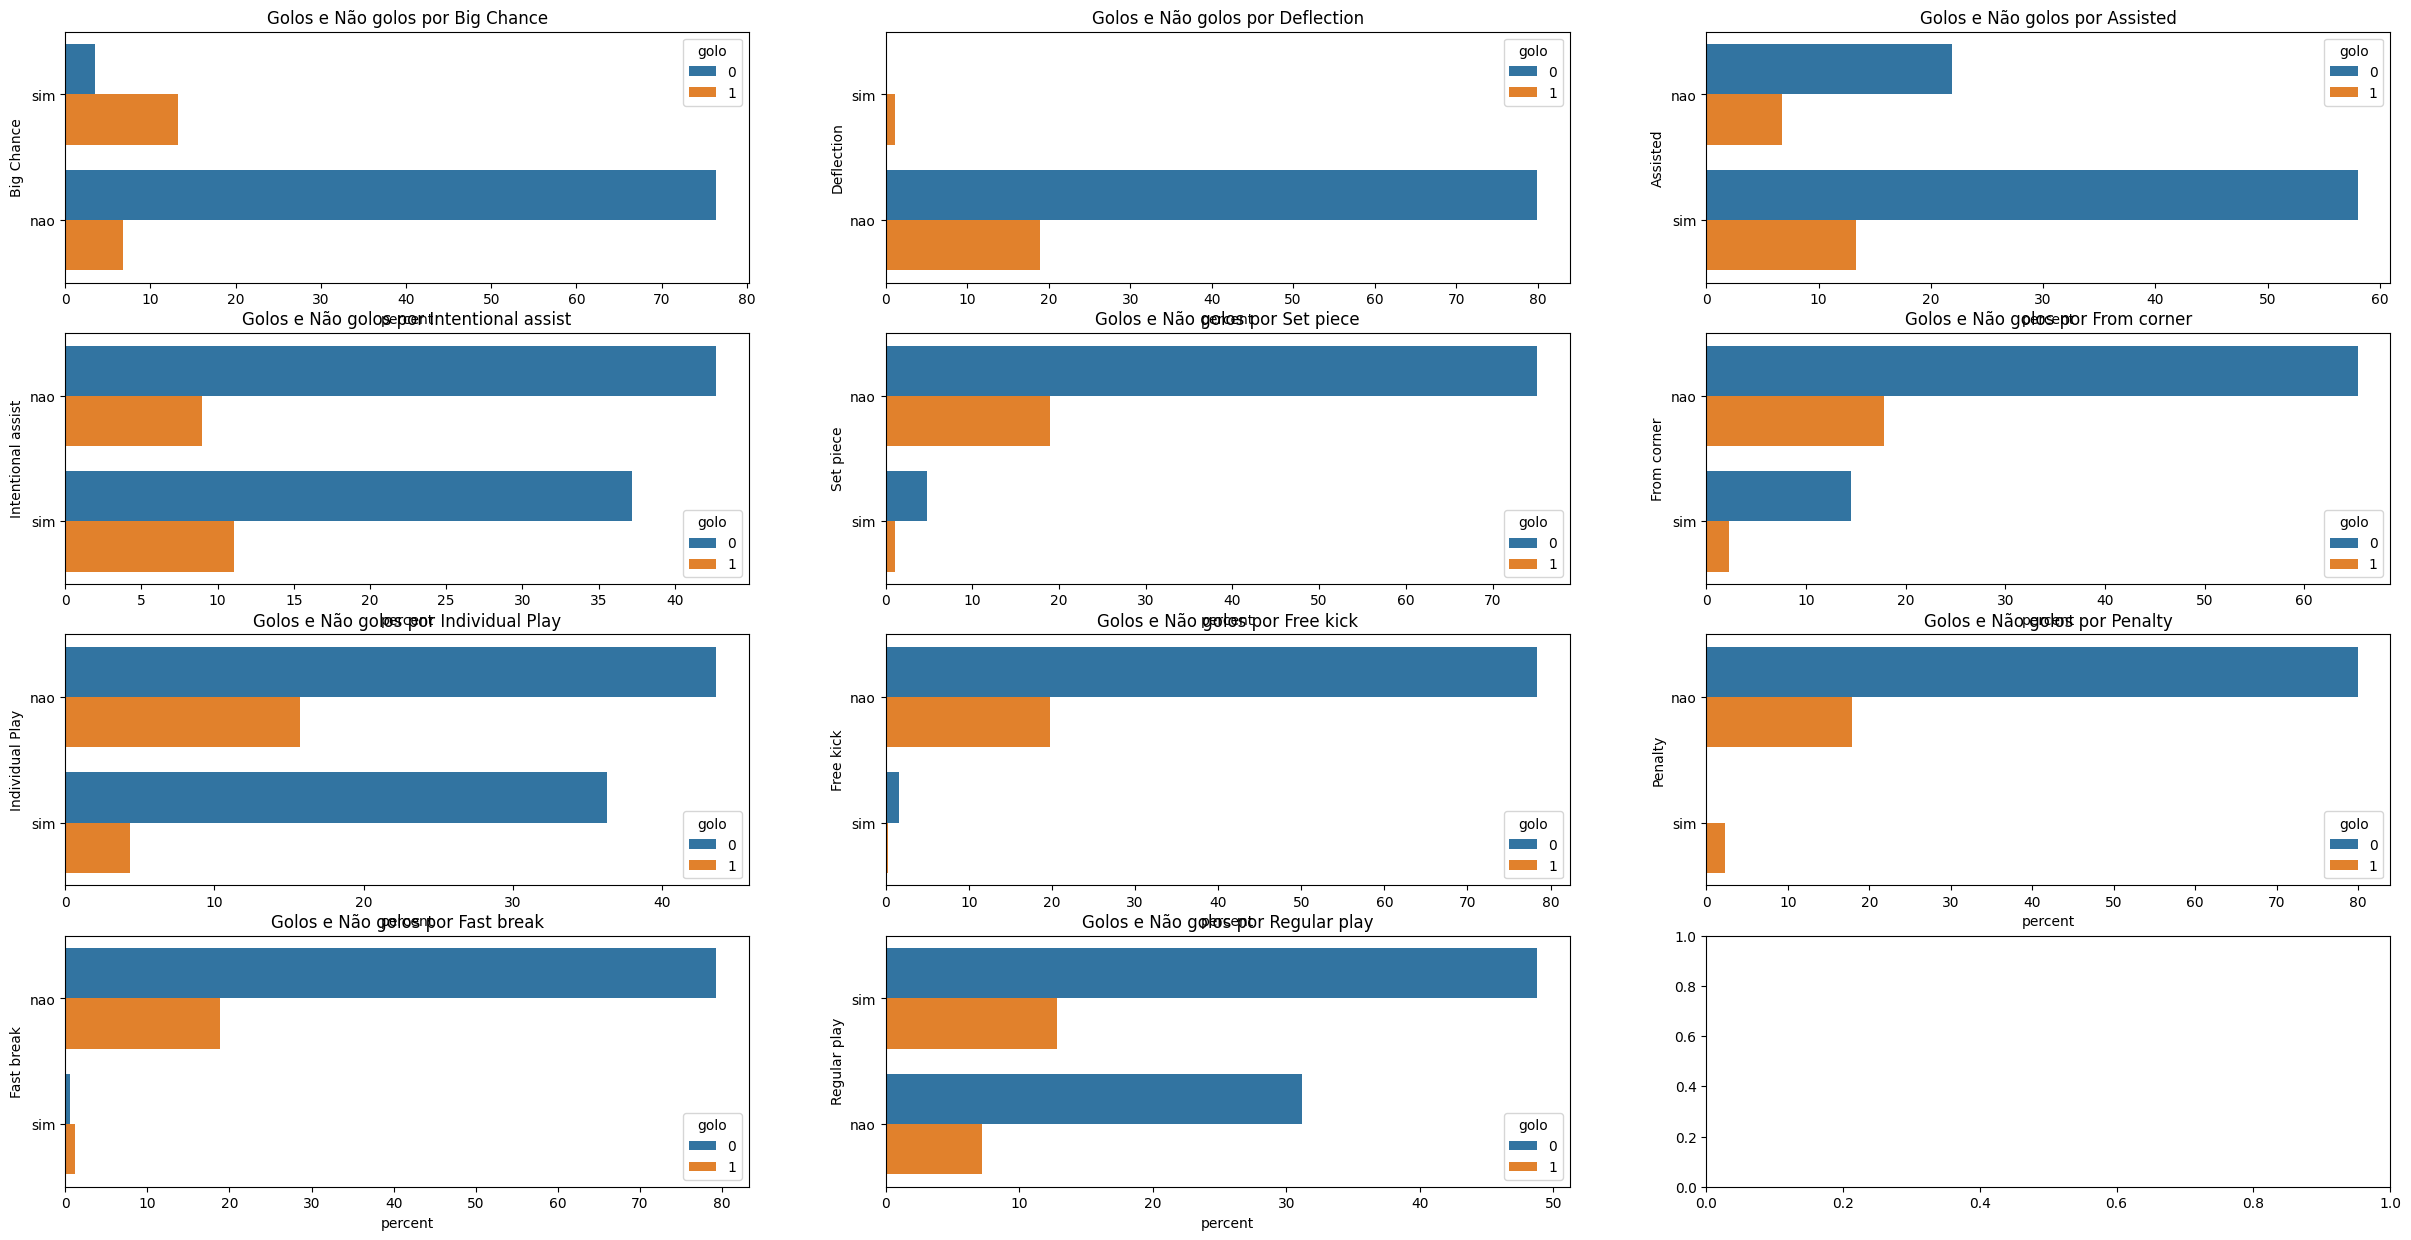

In [ ]:
colunas = ['Big Chance', 'Deflection', 'Assisted','Intentional assist', 'Set piece','From corner','Individual Play','Free kick','Penalty','Fast break','Regular play']
count=0

fig, ax = plt.subplots(4,3,figsize=(30,15))
ax = ax.flatten()
for coluna in colunas:
  sns.countplot(y=coluna, hue="golo", data=df, ax = ax[count],stat='percent')
  ax[count].set_title("Golos e Não golos por " + coluna)

  count = count + 1

In [ ]:
df = dataset_filtered.copy()

df["X"] = (100 - df['x']) * 105/100 # Inverte a abcissa do remate e calcula o valor proporcional num campo de 105 metros de comprimento
df["Y"] = df['y'] * 68/100           # Calcula o valor proporcional da ordenada do remate num campo de 68 metros de largura
df["C"] = abs(df['y'] - 50) * 68/100 # Calcula o valor da proporcional num campo de 68 metros de largura da distância da ordenada do remate e a ordenada central no campo

#calcular a distancia e o ângulo de remate
df["Distance"] = np.sqrt(df["X"]**2 + df["C"]**2)
df["Angle"] = np.where(np.arctan(7.32 * df["X"] / (df["X"]**2 + df["C"]**2 - (7.32/2)**2)) > 0, np.arctan(7.32 * df["X"] /(df["X"]**2 + df["C"]**2 - (7.32/2)**2)), np.arctan(7.32 * df["X"] /(df["X"]**2 + df["C"]**2 - (7.32/2)**2)) + np.pi)
df["Angle_new"] = np.where(np.pi/2 - np.arctan((df["C"]-7.32/2)/df["X"]) - np.arctan(df["X"]/(df["C"]+7.32/2)) > 0, np.pi/2 - np.arctan((df["C"]-7.32/2)/df["X"]) - np.arctan(df["X"]/(df["C"]+7.32/2)), np.pi/2 - np.arctan((df["C"]-7.32/2)/df["X"]) - np.arctan(df["X"]/(df["C"]+7.32/2)) + np.pi)

In [ ]:
df_treino = pd.DataFrame()
df_treino['Distance'] = df['Distance']
df_treino['Angle_new'] = df['Angle_new']
for feature in colunas:
  df_treino[feature] = df[feature]
df_treino['golo'] = df['golo']
df_treino = df_treino.replace('-', 'nao')
df_treino = df_treino.fillna('nao')
for feature in colunas:
  df_treino[feature] = df_treino[feature].replace({'sim':1 ,'nao':0})
df_treino

<ipython-input-61-972bdc93e43b>:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_treino[feature] = df_treino[feature].replace({'sim':1 ,'nao':0})


,Distance,Angle_new,Big Chance,Deflection,Assisted,Intentional assist,Set piece,From corner,Individual Play,Free kick,Penalty,Fast break,Regular play,golo
0,3.705698,1.558284,1,1,0,0,0,0,0,0,0,0,1,1
1,11.523044,0.475607,1,0,1,1,0,0,0,0,0,1,0,1
2,15.156071,0.467287,0,1,0,0,0,0,0,0,0,0,1,1
3,17.708799,0.368899,1,0,1,0,0,0,0,0,0,0,1,1
4,15.844329,0.427851,0,0,1,1,0,0,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3511,9.404578,0.710416,0,0,1,1,0,1,0,0,0,0,0,0
3512,12.492402,0.534976,0,0,1,1,0,1,0,0,0,0,0,0
3513,31.807091,0.225531,0,0,1,0,0,0,1,0,0,0,1,0
3514,31.060925,0.210903,0,0,1,0,0,0,1,0,0,0,1,0


In [ ]:
from sklearn.preprocessing import MinMaxScaler

sklearn_min_max = MinMaxScaler()
df_treino['Distance'] = sklearn_min_max.fit_transform(df_treino[['Distance']])
df_treino['Angle_new'] = sklearn_min_max.fit_transform(df_treino[['Angle_new']])

In [ ]:
X = df_treino[['Distance','Angle_new',"Big Chance"]]

y = df_treino['golo'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print ('Conjunto de treino: %d linhas\nConjunto de teste %d linhas' % (X_train.shape[0], X_test.shape[0]))

Conjunto de treino: 2785 linhas
Conjunto de teste 697 linhas


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
probability = model.predict_proba(X_test)
probability

array([[0.94695802, 0.05304198],
       [0.90347869, 0.09652131],
       [0.1932749 , 0.8067251 ],
       ...,
       [0.93947999, 0.06052001],
       [0.91035   , 0.08965   ],
       [0.9477471 , 0.0522529 ]])

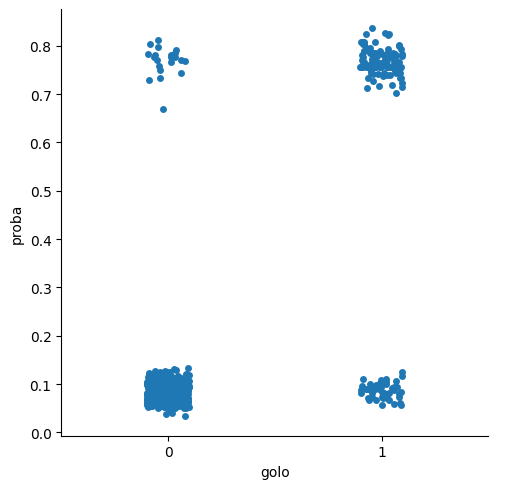

In [ ]:
goal_probability = list()
for res in probability:
  goal_probability.append(res[1])
data = pd.DataFrame(zip(y_test,goal_probability), columns=['golo','proba'])

sns.catplot(x='golo', y='proba',data=data)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94       541
           1       0.84      0.70      0.76       156

    accuracy                           0.90       697
   macro avg       0.88      0.83      0.85       697
weighted avg       0.90      0.90      0.90       697



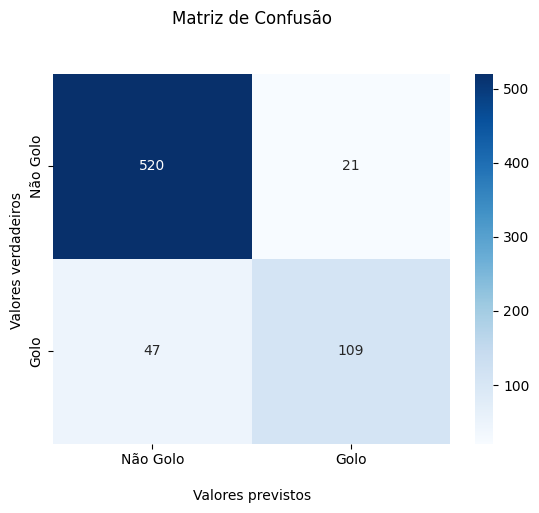

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')

ax.set_title('Matriz de Confusão\n\n');
ax.set_xlabel('\nValores previstos')
ax.set_ylabel('Valores verdadeiros ');

ax.xaxis.set_ticklabels(['Não Golo','Golo'])
ax.yaxis.set_ticklabels(['Não Golo','Golo'])

plt.show()

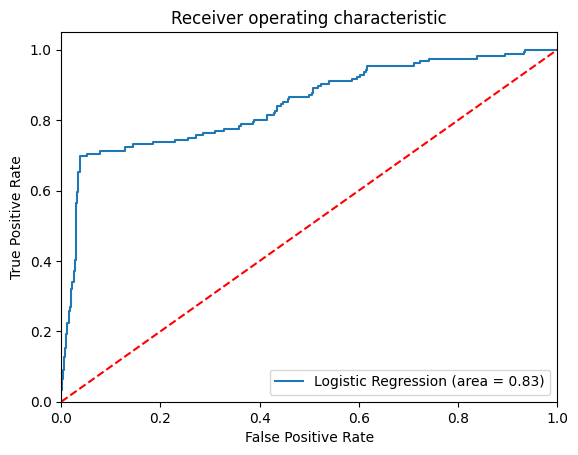

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

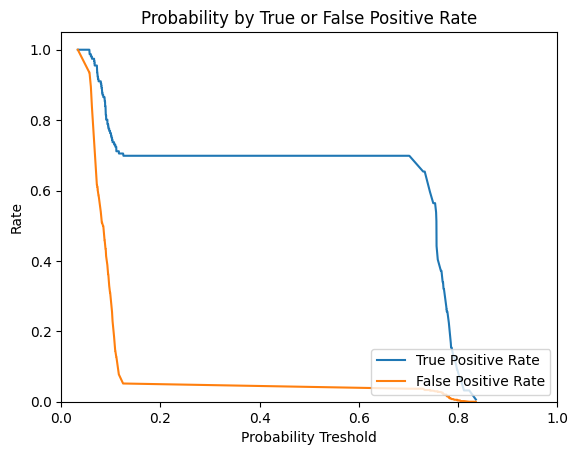

In [ ]:
plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Probability Treshold')
plt.ylabel('Rate')
plt.title('Probability by True or False Positive Rate')
plt.legend(loc="lower right")
plt.show()

Vamos verificar se introduzindo as restantes variáveis categóricas melhora o nosso modelo.

In [ ]:
X = df_treino[['Distance','Angle_new']+colunas]

y = df_treino['golo'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print ('Conjunto de treino: %d linhas\nConjunto de teste %d linhas' % (X_train.shape[0], X_test.shape[0]))

Conjunto de treino: 2785 linhas
Conjunto de teste 697 linhas


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
probability = model.predict_proba(X_test)
probability

array([[0.96763698, 0.03236302],
       [0.86733347, 0.13266653],
       [0.10651226, 0.89348774],
       ...,
       [0.94174315, 0.05825685],
       [0.87814804, 0.12185196],
       [0.93378097, 0.06621903]])

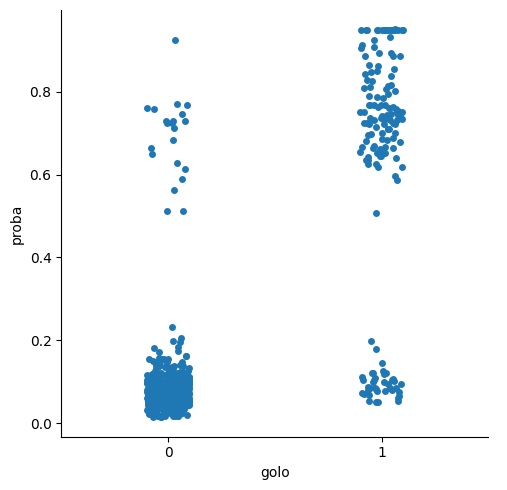

In [ ]:
goal_probability = list()
for res in probability:
  goal_probability.append(res[1])
data = pd.DataFrame(zip(y_test,goal_probability), columns=['golo','proba'])

sns.catplot(x='golo', y='proba',data=data)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       541
           1       0.85      0.75      0.80       156

    accuracy                           0.91       697
   macro avg       0.89      0.86      0.87       697
weighted avg       0.91      0.91      0.91       697



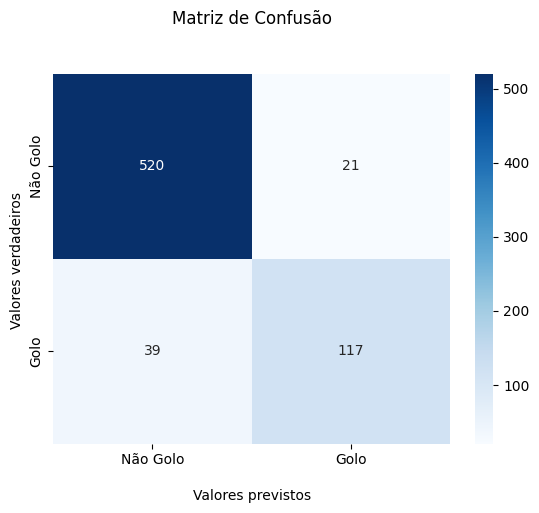

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')

ax.set_title('Matriz de Confusão\n\n');
ax.set_xlabel('\nValores previstos')
ax.set_ylabel('Valores verdadeiros ');

ax.xaxis.set_ticklabels(['Não Golo','Golo'])
ax.yaxis.set_ticklabels(['Não Golo','Golo'])

plt.show()

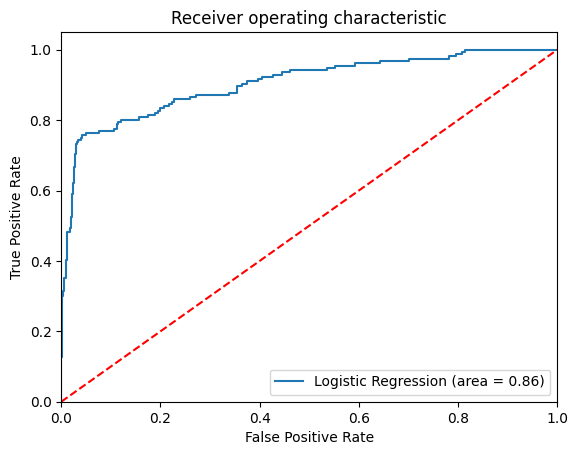

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

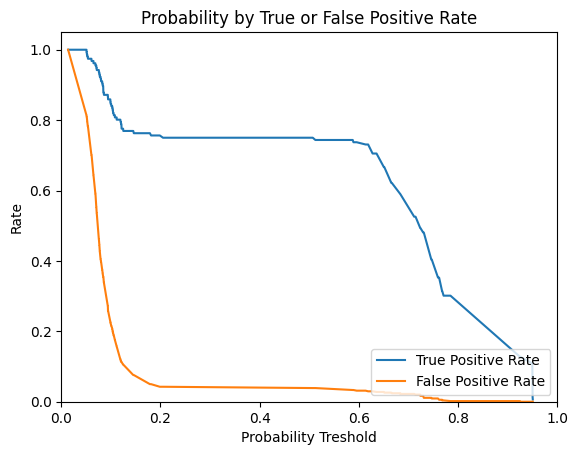

In [ ]:
plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Probability Treshold')
plt.ylabel('Rate')
plt.title('Probability by True or False Positive Rate')
plt.legend(loc="lower right")
plt.show()

Vamos verificar quais das variáveis introduzidas melhorou a performance com um feature importance

Feature: 0, Score: -2.49545
Feature: 1, Score: 1.04623
Feature: 2, Score: 2.99193
Feature: 3, Score: 3.70865
Feature: 4, Score: -0.20191
Feature: 5, Score: 0.06034
Feature: 6, Score: 0.45122
Feature: 7, Score: 0.38444
Feature: 8, Score: 0.45911
Feature: 9, Score: 1.70169
Feature: 10, Score: 2.97406
Feature: 11, Score: 2.03685
Feature: 12, Score: 1.01563


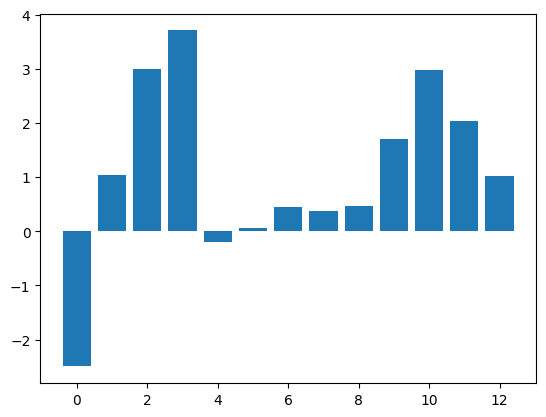

In [ ]:
# logistic regression for feature importance
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot
# get importance
importance = model.coef_[0]
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

As variáveis Assistes, Intentional assist, set piece, from corner e individual play não têm grande poder preditivo. Vamos retirá-las

In [ ]:
X = df_treino[['Distance','Angle_new','Big Chance', 'Deflection','Free kick','Penalty','Fast break','Regular play']]

y = df_treino['golo'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print ('Conjunto de treino: %d linhas\nConjunto de teste %d linhas' % (X_train.shape[0], X_test.shape[0]))

Conjunto de treino: 2785 linhas
Conjunto de teste 697 linhas


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
probability = model.predict_proba(X_test)
probability

array([[0.97613447, 0.02386553],
       [0.89427964, 0.10572036],
       [0.17515395, 0.82484605],
       ...,
       [0.94120306, 0.05879694],
       [0.89779233, 0.10220767],
       [0.92044894, 0.07955106]])

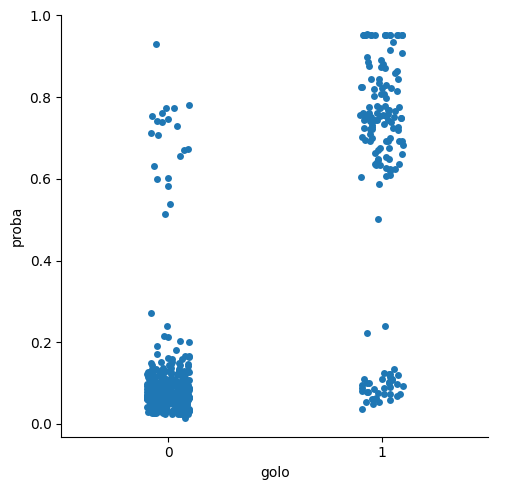

In [ ]:
goal_probability = list()
for res in probability:
  goal_probability.append(res[1])
data = pd.DataFrame(zip(y_test,goal_probability), columns=['golo','proba'])

sns.catplot(x='golo', y='proba',data=data)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       541
           1       0.85      0.75      0.80       156

    accuracy                           0.91       697
   macro avg       0.89      0.86      0.87       697
weighted avg       0.91      0.91      0.91       697



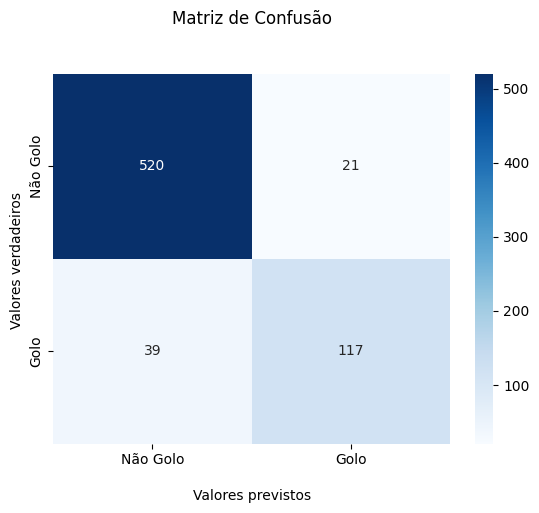

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')

ax.set_title('Matriz de Confusão\n\n');
ax.set_xlabel('\nValores previstos')
ax.set_ylabel('Valores verdadeiros ');

ax.xaxis.set_ticklabels(['Não Golo','Golo'])
ax.yaxis.set_ticklabels(['Não Golo','Golo'])

plt.show()

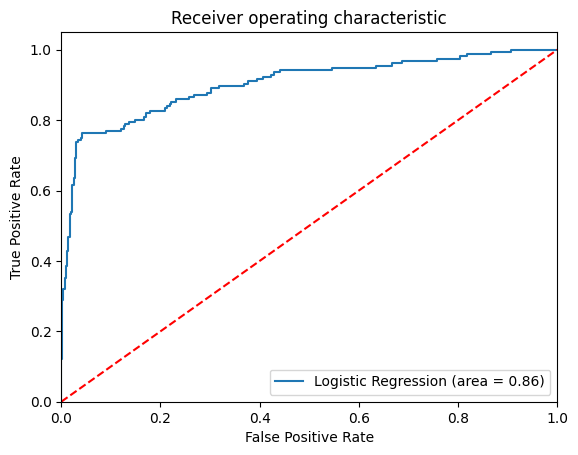

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

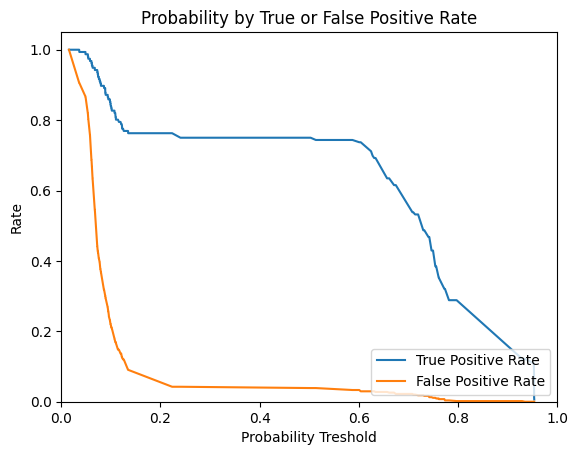

In [ ]:
plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Probability Treshold')
plt.ylabel('Rate')
plt.title('Probability by True or False Positive Rate')
plt.legend(loc="lower right")
plt.show()

Vamos verificar o próximo bloco de variáveis categóricas.
Swerve right e swerve left não são mutuamente exclusivas

In [ ]:
#df_raw = dataset_filtered[['Right footed','Left footed', 'Head','Swerve Right','Swerve Left','Other body part','golo']]
df_raw = dataset_filtered[['Right footed','Left footed', 'Head','Other body part','golo']]
df_raw.head(10)

,Right footed,Left footed,Head,Other body part,golo
0,sim,NaN,NaN,NaN,1
1,-,sim,NaN,NaN,1
2,sim,-,NaN,NaN,1
3,sim,-,NaN,NaN,1
4,sim,-,NaN,NaN,1
5,-,sim,NaN,NaN,1
6,sim,-,NaN,NaN,1
7,-,-,NaN,NaN,1
8,-,sim,NaN,NaN,1
9,-,sim,NaN,NaN,1


In [ ]:
df_raw.isna().sum()

,0
Right footed,242
Left footed,941
Head,966
Other body part,3457
golo,0


In [ ]:
df = df_raw.replace('-', 'nao')
df = df.fillna('nao')

df_aux = df[['Right footed','Left footed', 'Head','Other body part']]
df_aux.eq(df.iloc[:, 0], axis=0)
print("Existem " + str(len(np.where(df_aux.eq(df_aux.iloc[:, 0], axis=0).all(1))[0])) + " casos em que todos as variaveis são identicas.")

Existem 116 casos em que todos as variaveis são identicas.


In [ ]:
for i in np.where(df_aux.eq(df_aux.iloc[:, 0], axis=0).all(1))[0]:
  df.loc[i,'Other body part'] = 'sim'

df.eq(df.iloc[:, 0], axis=0)
print("Existem " + str(len(np.where(df.eq(df.iloc[:, 0], axis=0).all(1))[0])) + " casos em que todos as variaveis são identicas.")

Existem 0 casos em que todos as variaveis são identicas.


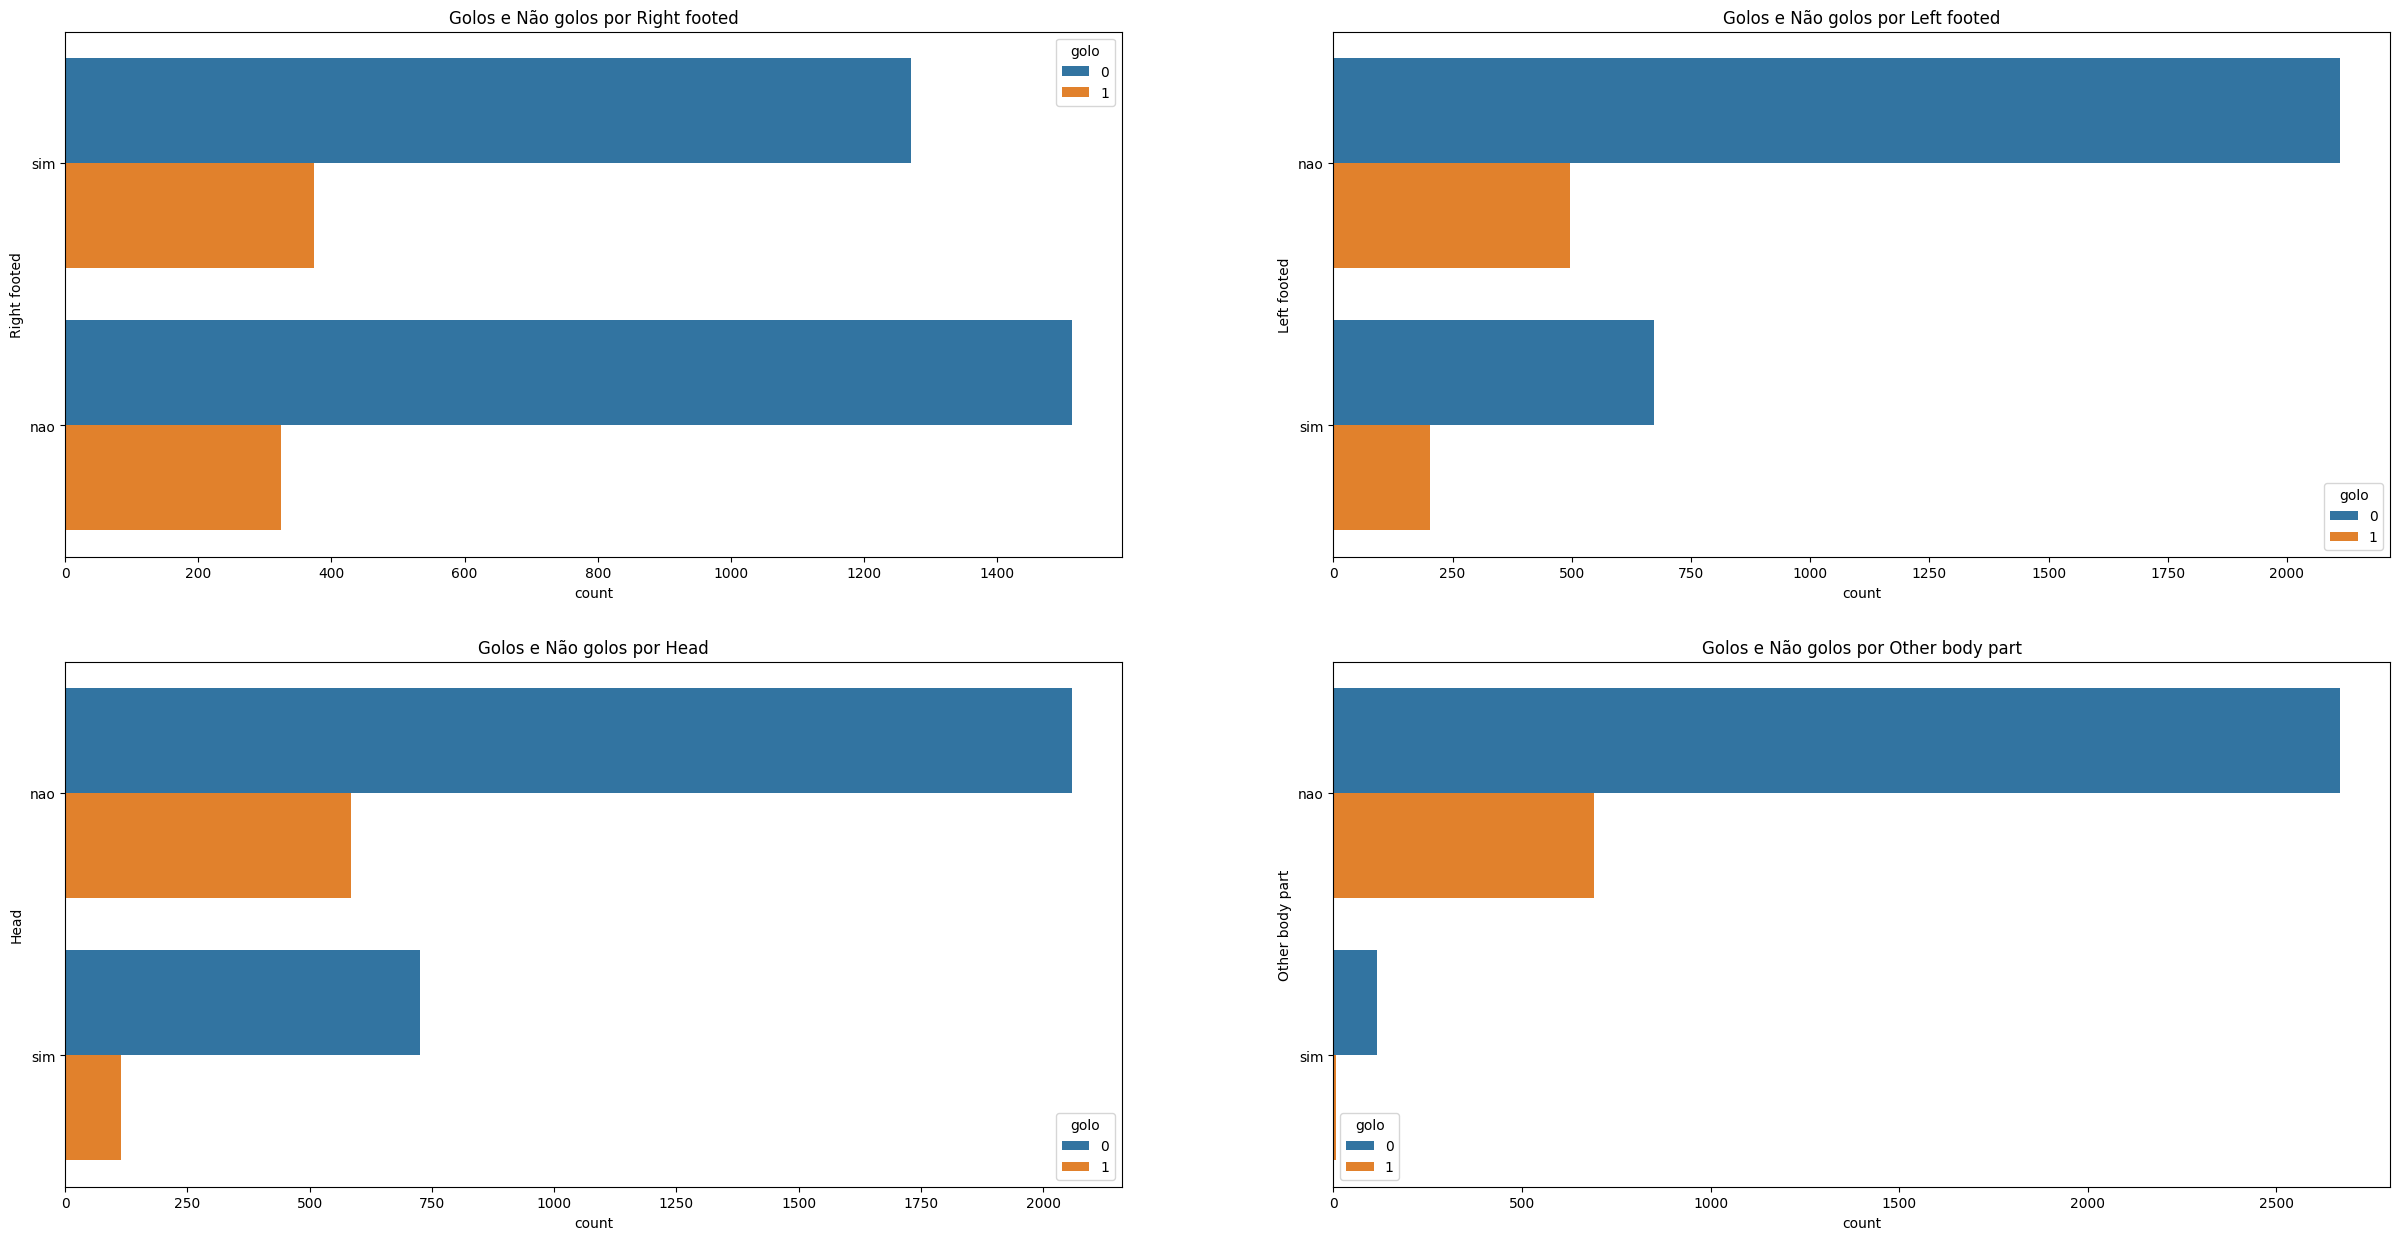

In [ ]:
colunas = ['Right footed','Left footed', 'Head','Other body part']
count=0

fig, ax = plt.subplots(2,2,figsize=(30,15))
ax = ax.flatten()
for coluna in colunas:
  sns.countplot(y=coluna, hue="golo", data=df, ax = ax[count])
  ax[count].set_title("Golos e Não golos por " + coluna)

  count = count + 1

In [ ]:
df.head()

,Right footed,Left footed,Head,Other body part,golo
0,sim,nao,nao,nao,1
1,nao,sim,nao,nao,1
2,sim,nao,nao,nao,1
3,sim,nao,nao,nao,1
4,sim,nao,nao,nao,1


In [ ]:
df_treino.head()

,Distance,Angle_new,Big Chance,Deflection,Assisted,Intentional assist,Set piece,From corner,Individual Play,Free kick,Penalty,Fast break,Regular play,golo
0,0.042926,0.632900,1,1,0,0,0,0,0,0,0,0,1,1
1,0.201707,0.187217,1,0,1,1,0,0,0,0,0,1,0,1
2,0.275499,0.183792,0,1,0,0,0,0,0,0,0,0,1,1
3,0.327349,0.143291,1,0,1,0,0,0,0,0,0,0,1,1
4,0.289479,0.167559,0,0,1,1,0,0,0,0,0,0,1,1


In [ ]:
for feature in ['Right footed','Left footed', 'Head','Other body part']:
  df_treino[feature] = df[feature].replace({'sim':1 ,'nao':0})
df_treino

<ipython-input-98-b1b686cc9e3c>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_treino[feature] = df[feature].replace({'sim':1 ,'nao':0})
<ipython-input-98-b1b686cc9e3c>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_treino[feature] = df[feature].replace({'sim':1 ,'nao':0})
<ipython-input-98-b1b686cc9e3c>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior,

,Distance,Angle_new,Big Chance,Deflection,Assisted,Intentional assist,Set piece,From corner,Individual Play,Free kick,Penalty,Fast break,Regular play,golo,Right footed,Left footed,Head,Other body part
0,0.042926,0.632900,1,1,0,0,0,0,0,0,0,0,1,1,1,0,0,0
1,0.201707,0.187217,1,0,1,1,0,0,0,0,0,1,0,1,0,1,0,0
2,0.275499,0.183792,0,1,0,0,0,0,0,0,0,0,1,1,1,0,0,0
3,0.327349,0.143291,1,0,1,0,0,0,0,0,0,0,1,1,1,0,0,0
4,0.289479,0.167559,0,0,1,1,0,0,0,0,0,0,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3511,0.158678,0.283876,0,0,1,1,0,1,0,0,0,0,0,0,0,0,0,0
3512,0.221396,0.211656,0,0,1,1,0,1,0,0,0,0,0,0,0,1,0,0
3513,0.613705,0.084273,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0
3514,0.598549,0.078252,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0


In [ ]:
X = df_treino[['Distance','Angle_new','Big Chance', 'Deflection','Free kick','Penalty','Fast break','Regular play','Right footed','Left footed', 'Head','Other body part']]

y = df_treino['golo'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print ('Conjunto de treino: %d linhas\nConjunto de teste %d linhas' % (X_train.shape[0], X_test.shape[0]))

Conjunto de treino: 2785 linhas
Conjunto de teste 697 linhas


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
probability = model.predict_proba(X_test)
probability

array([[0.97336434, 0.02663566],
       [0.87400322, 0.12599678],
       [0.23733929, 0.76266071],
       ...,
       [0.94202276, 0.05797724],
       [0.87972995, 0.12027005],
       [0.92248295, 0.07751705]])

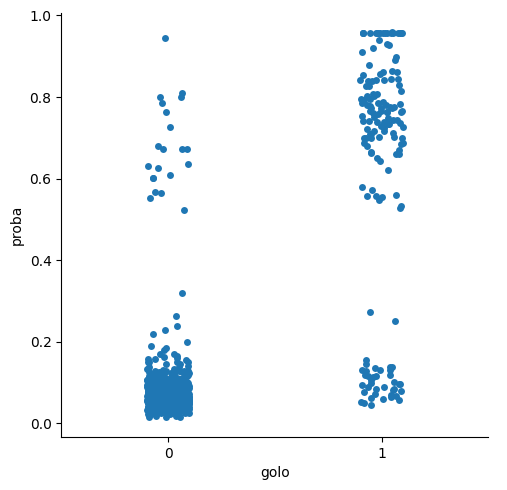

In [ ]:
goal_probability = list()
for res in probability:
  goal_probability.append(res[1])
data = pd.DataFrame(zip(y_test,goal_probability), columns=['golo','proba'])

sns.catplot(x='golo', y='proba',data=data)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       541
           1       0.85      0.75      0.80       156

    accuracy                           0.91       697
   macro avg       0.89      0.86      0.87       697
weighted avg       0.91      0.91      0.91       697



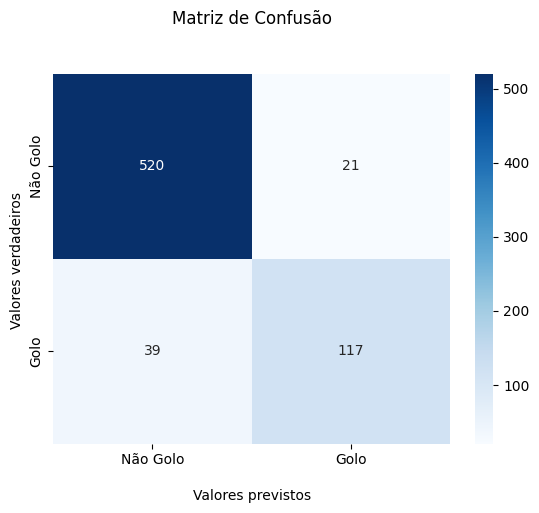

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')

ax.set_title('Matriz de Confusão\n\n');
ax.set_xlabel('\nValores previstos')
ax.set_ylabel('Valores verdadeiros ');

ax.xaxis.set_ticklabels(['Não Golo','Golo'])
ax.yaxis.set_ticklabels(['Não Golo','Golo'])

plt.show()

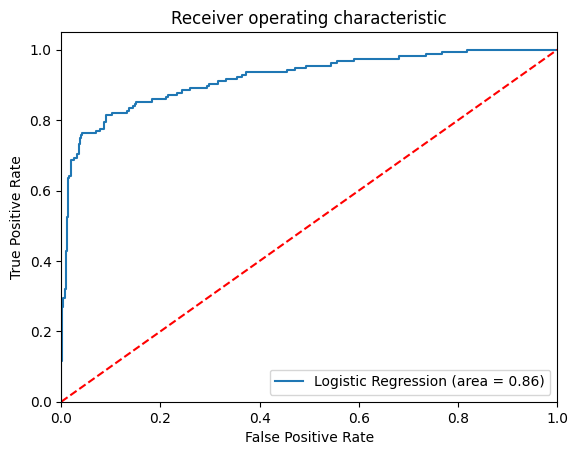

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

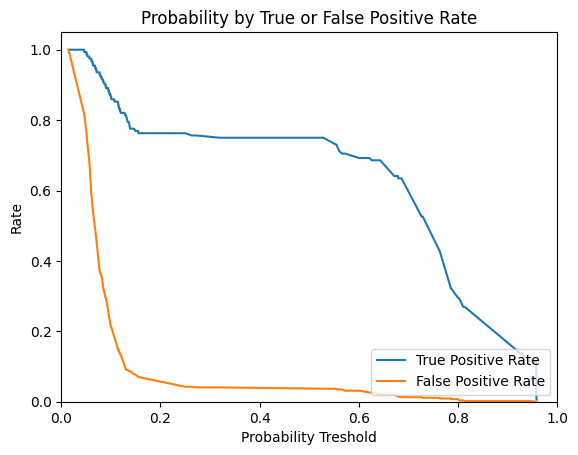

In [ ]:
plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Probability Treshold')
plt.ylabel('Rate')
plt.title('Probability by True or False Positive Rate')
plt.legend(loc="lower right")
plt.show()

As variáveis introduzidas não melhoram a performance do modelo.
Vamos ficar apenas com as anteriores.
Vamos analisar as variáveis de posição.

In [ ]:
df_raw = dataset_filtered[['Box-centre','Box-left', 'Box-right','Small box-right','Small box-left','Small box-centre','Box-deep right','Box-deep left','Out of box-centre','golo']]
df_raw

,Box-centre,Box-left,Box-right,Small box-right,Small box-left,Small box-centre,Box-deep right,Box-deep left,Out of box-centre,golo
0,NaN,NaN,NaN,NaN,NaN,sim,NaN,NaN,NaN,1
1,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...
3511,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,0
3512,sim,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-,0
3513,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sim,0
3514,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,sim,0


In [ ]:
df_aux = df_raw
df_aux.eq(df_aux.iloc[:, 0], axis=0)
print("Existem " + str(len(np.where(df_aux.eq(df_aux.iloc[:, 0], axis=0).all(1))[0])) + " casos em que todos as variaveis são identicas.")

Existem 0 casos em que todos as variaveis são identicas.


In [ ]:
df = df_raw.replace('-', 'nao')
df = df.fillna('nao')

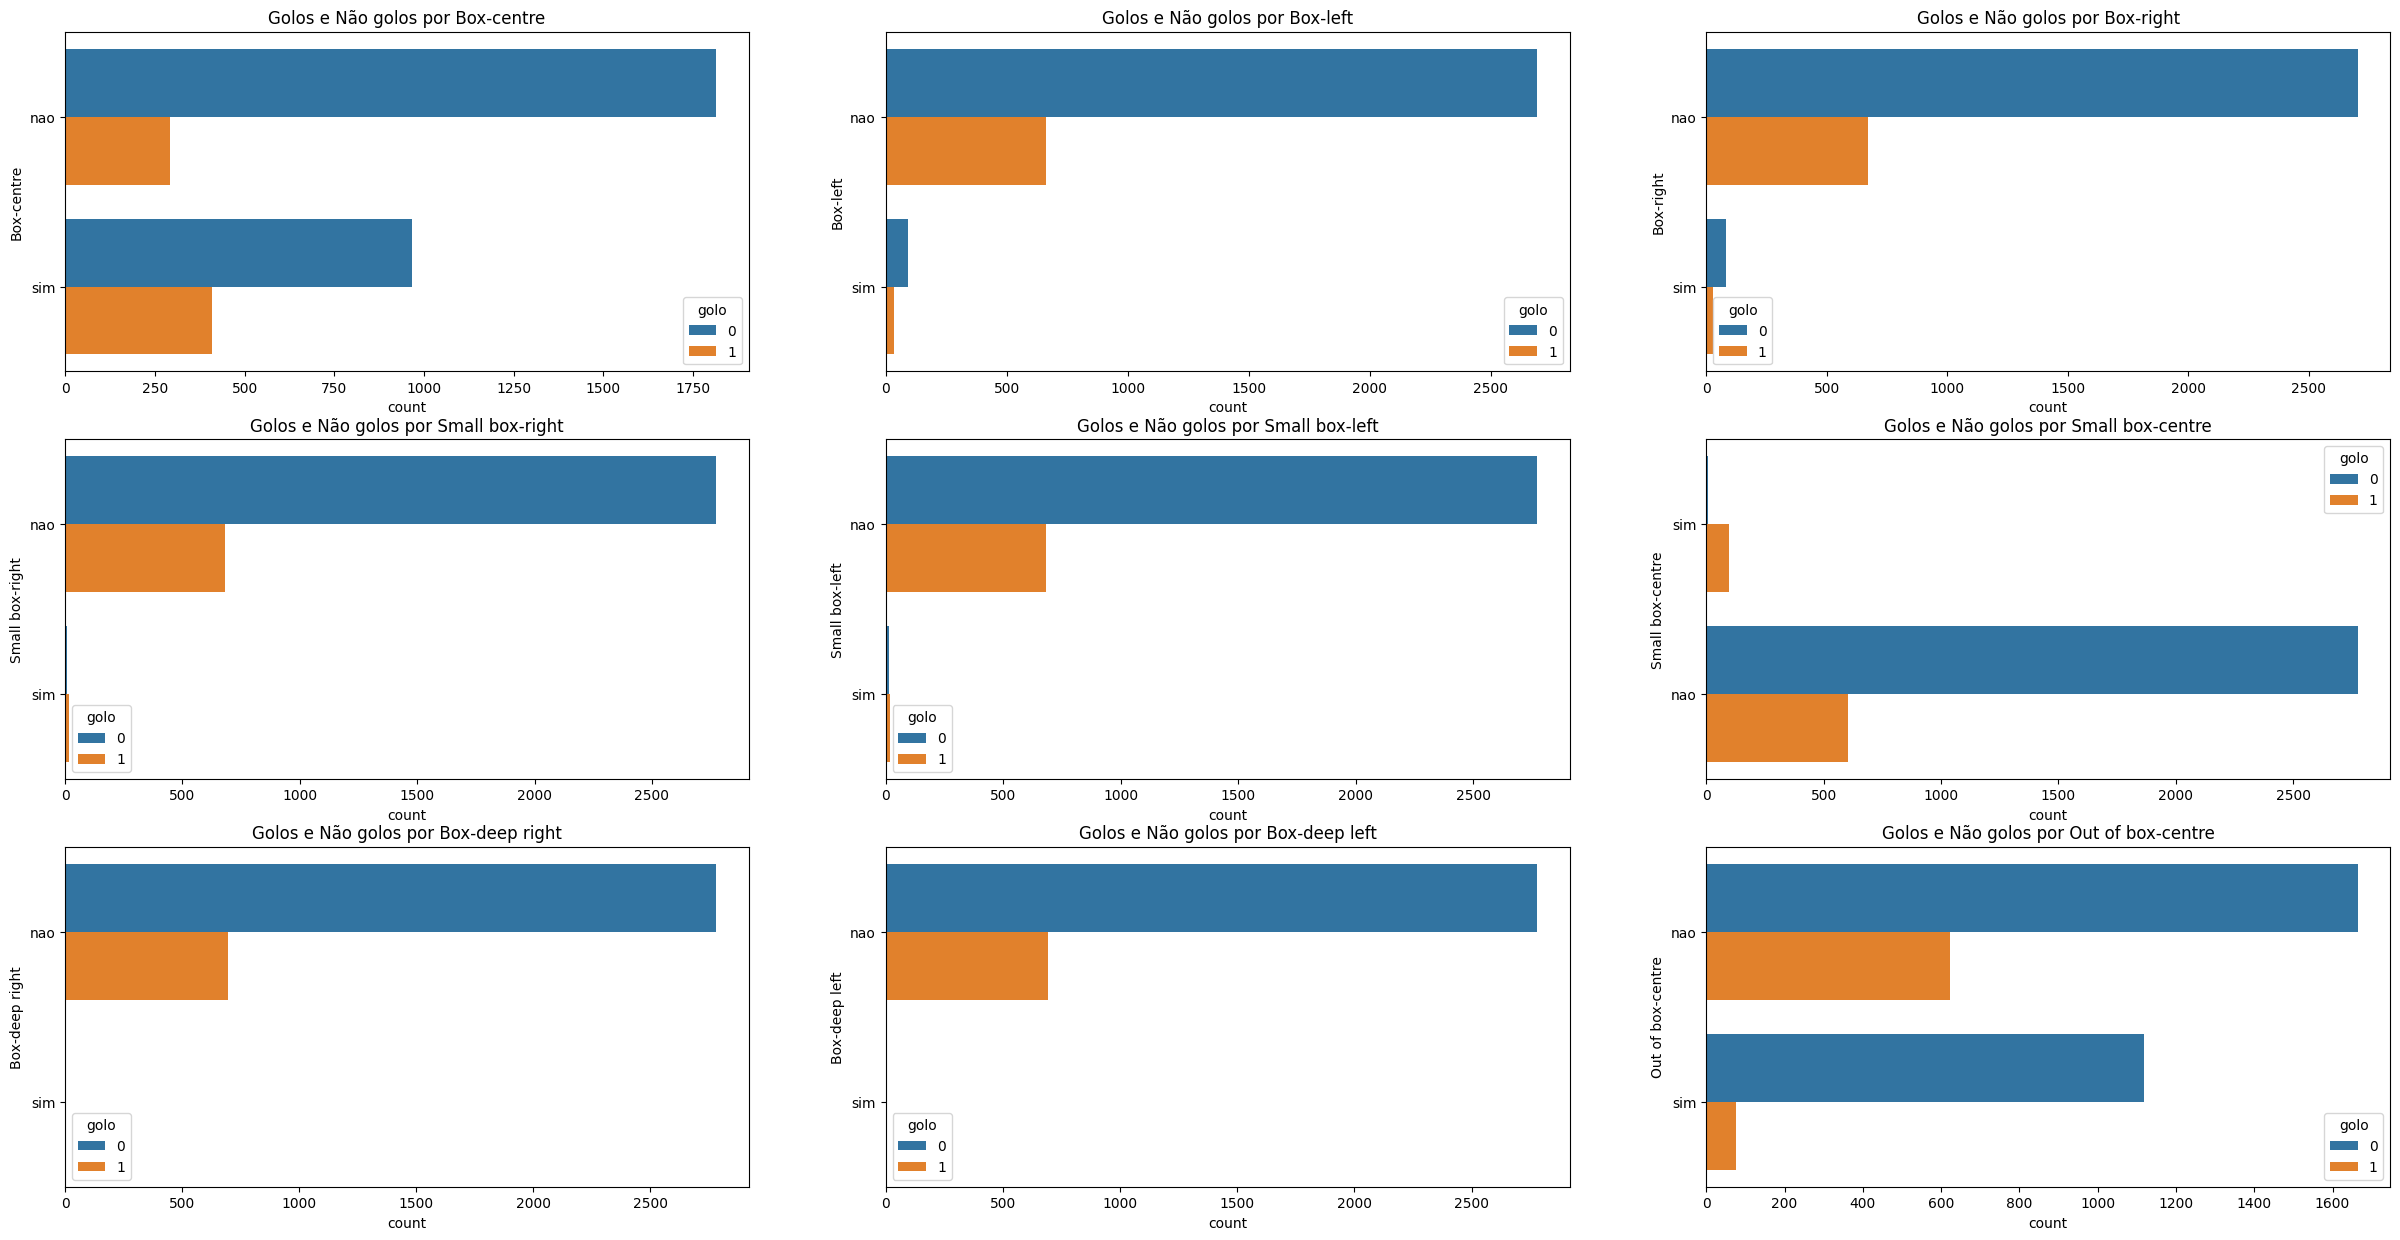

In [ ]:
colunas = ['Box-centre','Box-left', 'Box-right','Small box-right','Small box-left','Small box-centre','Box-deep right','Box-deep left','Out of box-centre']
count=0

fig, ax = plt.subplots(3,3,figsize=(30,15))
ax = ax.flatten()
for coluna in colunas:
  sns.countplot(y=coluna, hue="golo", data=df, ax = ax[count])
  ax[count].set_title("Golos e Não golos por " + coluna)

  count = count + 1

In [ ]:
for feature in ['Box-centre','Box-left', 'Box-right','Small box-right','Small box-left','Small box-centre','Box-deep right','Box-deep left','Out of box-centre']:
  df_treino[feature] = df[feature].replace({'sim':1 ,'nao':0})
df_treino

<ipython-input-111-2217972c3537>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_treino[feature] = df[feature].replace({'sim':1 ,'nao':0})
<ipython-input-111-2217972c3537>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_treino[feature] = df[feature].replace({'sim':1 ,'nao':0})
<ipython-input-111-2217972c3537>:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavi

,Distance,Angle_new,Big Chance,Deflection,Assisted,Intentional assist,Set piece,From corner,Individual Play,Free kick,...,Other body part,Box-centre,Box-left,Box-right,Small box-right,Small box-left,Small box-centre,Box-deep right,Box-deep left,Out of box-centre
0,0.042926,0.632900,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,0.201707,0.187217,1,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,0.275499,0.183792,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0.327349,0.143291,1,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,0.289479,0.167559,0,0,1,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3511,0.158678,0.283876,0,0,1,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
3512,0.221396,0.211656,0,0,1,1,0,1,0,0,...,0,1,0,0,0,0,0,0,0,0
3513,0.613705,0.084273,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3514,0.598549,0.078252,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
X = df_treino[['Distance','Angle_new','Big Chance', 'Deflection','Free kick','Penalty','Fast break','Regular play','Box-centre','Box-left', 'Box-right','Small box-right','Small box-left','Small box-centre','Box-deep right','Box-deep left','Out of box-centre']]

y = df_treino['golo'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print ('Conjunto de treino: %d linhas\nConjunto de teste %d linhas' % (X_train.shape[0], X_test.shape[0]))

Conjunto de treino: 2785 linhas
Conjunto de teste 697 linhas


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
probability = model.predict_proba(X_test)
probability

array([[0.97496205, 0.02503795],
       [0.95728549, 0.04271451],
       [0.05657036, 0.94342964],
       ...,
       [0.94500789, 0.05499211],
       [0.86181846, 0.13818154],
       [0.93537645, 0.06462355]])

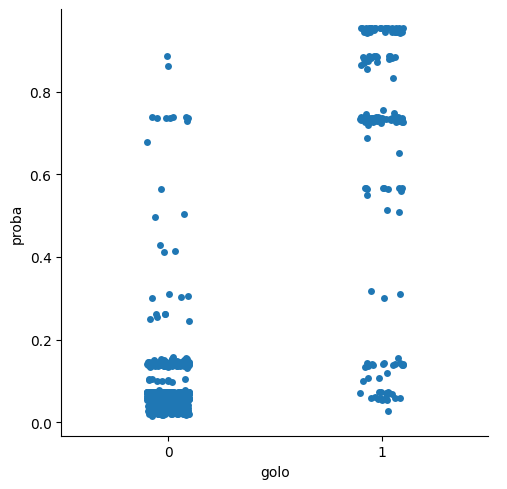

In [ ]:
goal_probability = list()
for res in probability:
  goal_probability.append(res[1])
data = pd.DataFrame(zip(y_test,goal_probability), columns=['golo','proba'])

sns.catplot(x='golo', y='proba',data=data)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       541
           1       0.90      0.75      0.82       156

    accuracy                           0.93       697
   macro avg       0.92      0.86      0.89       697
weighted avg       0.92      0.93      0.92       697



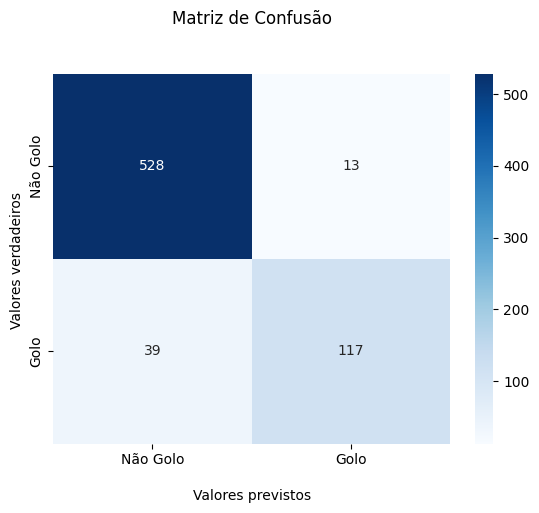

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')

ax.set_title('Matriz de Confusão\n\n');
ax.set_xlabel('\nValores previstos')
ax.set_ylabel('Valores verdadeiros ');

ax.xaxis.set_ticklabels(['Não Golo','Golo'])
ax.yaxis.set_ticklabels(['Não Golo','Golo'])

plt.show()

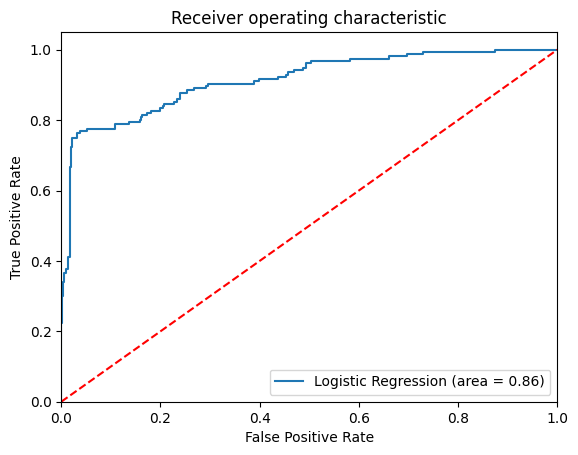

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

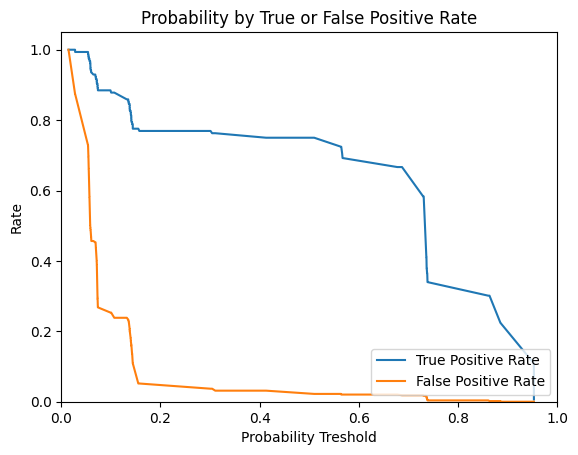

In [ ]:
plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Probability Treshold')
plt.ylabel('Rate')
plt.title('Probability by True or False Positive Rate')
plt.legend(loc="lower right")
plt.show()

As variáveis introduzidas melhoram a performance do modelo.
Vamos analisar a sua importancia para verificar com quais ficar.

Feature: 0, Score: -0.48854
Feature: 1, Score: -0.06684
Feature: 2, Score: 2.80111
Feature: 3, Score: 3.75220
Feature: 4, Score: 1.43156
Feature: 5, Score: 2.77570
Feature: 6, Score: 1.78026
Feature: 7, Score: 0.77048
Feature: 8, Score: 1.32173
Feature: 9, Score: 1.44876
Feature: 10, Score: 1.33702
Feature: 11, Score: 2.11700
Feature: 12, Score: 2.05769
Feature: 13, Score: 3.07919
Feature: 14, Score: 1.10596
Feature: 15, Score: 2.00158
Feature: 16, Score: 0.43994


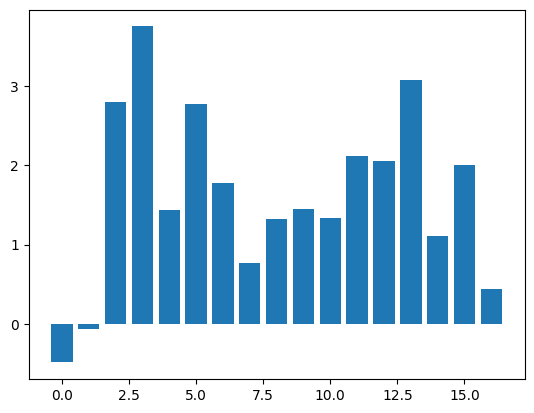

In [ ]:
# logistic regression for feature importance
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from matplotlib import pyplot
# get importance
importance = model.coef_[0]
# summarize feature importance
for i,v in enumerate(importance):
	print('Feature: %0d, Score: %.5f' % (i,v))
# plot feature importance
pyplot.bar([x for x in range(len(importance))], importance)
pyplot.show()

A variável angle não tem grande poder preditivo. Vamos retirá-la.

In [ ]:
X = df_treino[['Distance','Big Chance', 'Deflection','Free kick','Penalty','Fast break','Regular play','Box-centre','Box-left', 'Box-right','Small box-right','Small box-left','Small box-centre','Box-deep right','Box-deep left','Out of box-centre']]
y = df_treino['golo'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print ('Conjunto de treino: %d linhas\nConjunto de teste %d linhas' % (X_train.shape[0], X_test.shape[0]))

Conjunto de treino: 2785 linhas
Conjunto de teste 697 linhas


In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [ ]:
probability = model.predict_proba(X_test)
probability

array([[0.97506364, 0.02493636],
       [0.9578358 , 0.0421642 ],
       [0.05779597, 0.94220403],
       ...,
       [0.94488015, 0.05511985],
       [0.8616592 , 0.1383408 ],
       [0.93690914, 0.06309086]])

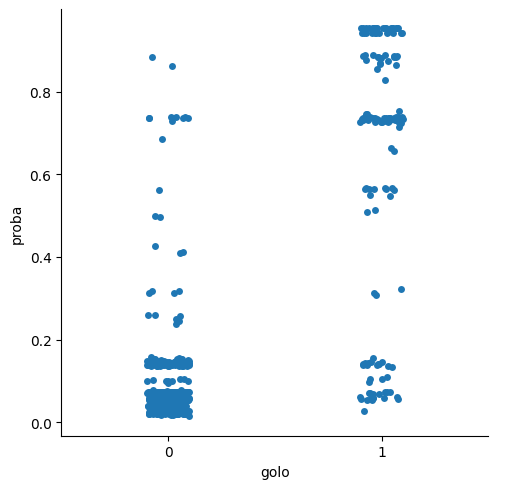

In [ ]:
goal_probability = list()
for res in probability:
  goal_probability.append(res[1])
data = pd.DataFrame(zip(y_test,goal_probability), columns=['golo','proba'])

sns.catplot(x='golo', y='proba',data=data)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       541
           1       0.91      0.75      0.82       156

    accuracy                           0.93       697
   macro avg       0.92      0.86      0.89       697
weighted avg       0.93      0.93      0.92       697



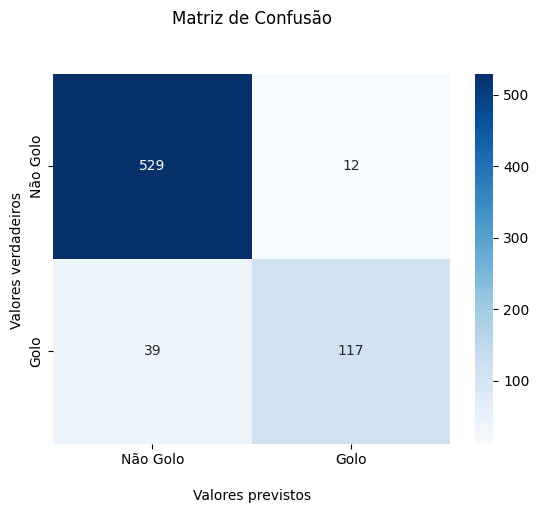

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')

ax.set_title('Matriz de Confusão\n\n');
ax.set_xlabel('\nValores previstos')
ax.set_ylabel('Valores verdadeiros ');

ax.xaxis.set_ticklabels(['Não Golo','Golo'])
ax.yaxis.set_ticklabels(['Não Golo','Golo'])

plt.show()

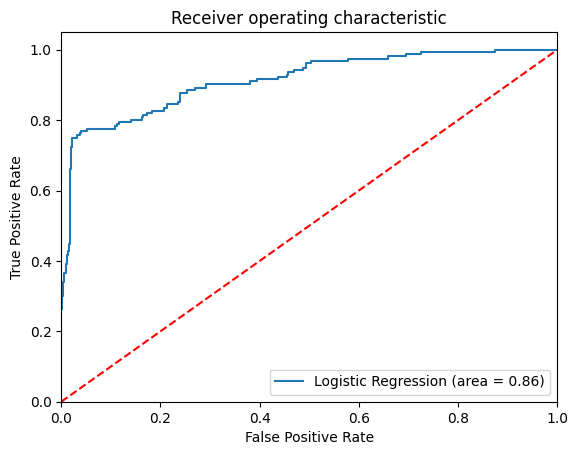

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

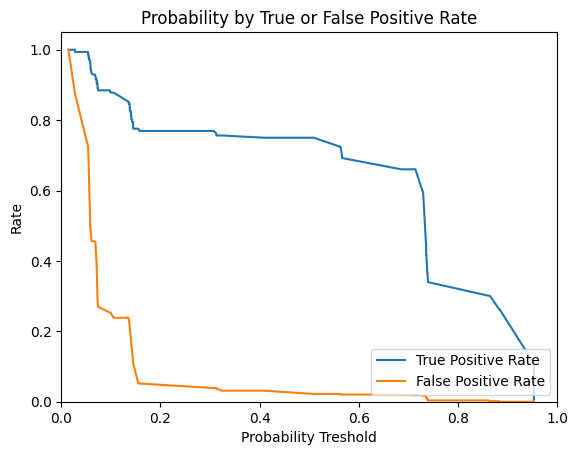

In [ ]:
plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Probability Treshold')
plt.ylabel('Rate')
plt.title('Probability by True or False Positive Rate')
plt.legend(loc="lower right")
plt.show()

Experimentar outros modelos

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train,y_train)


KNeighborsClassifier(n_neighbors=3)

In [ ]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       541
           1       0.83      0.67      0.74       156

    accuracy                           0.89       697
   macro avg       0.87      0.81      0.84       697
weighted avg       0.89      0.89      0.89       697



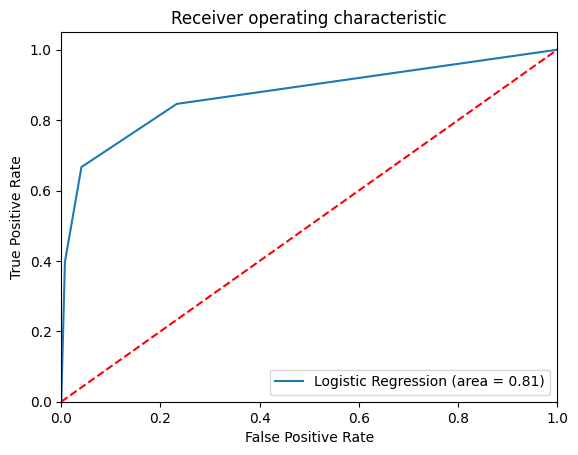

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

In [ ]:
import xgboost as xgb



dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)
# specify parameters via map
param = {'max_depth':2, 'eta':0.3,'objective': 'multi:softprob',
    'num_class': 2}

num_round =3
bst = xgb.XGBClassifier()
bst = xgb.train(param, dtrain, num_round)


In [ ]:
from sklearn.metrics import classification_report

y_pred = bst.predict(dtest)
best_preds = np.asarray([np.argmax(line) for line in y_pred])
print(classification_report(y_test, best_preds))

              precision    recall  f1-score   support

           0       0.93      0.96      0.95       541
           1       0.85      0.75      0.80       156

    accuracy                           0.91       697
   macro avg       0.89      0.86      0.87       697
weighted avg       0.91      0.91      0.91       697



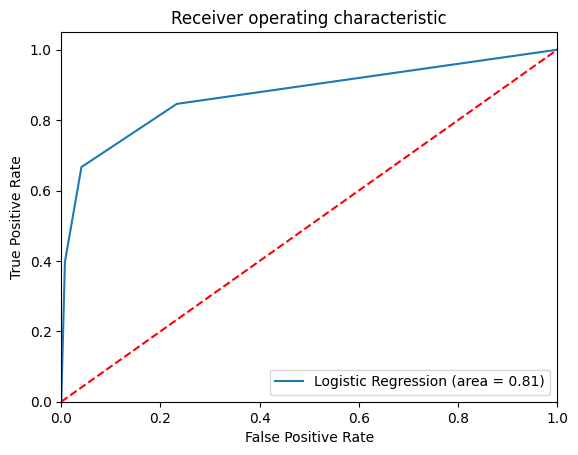

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, model.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

Grid search on logistic regression

In [ ]:
X = df_treino[['Distance','Big Chance', 'Deflection','Free kick','Penalty','Fast break','Regular play','Box-centre','Box-left', 'Box-right','Small box-right','Small box-left','Small box-centre','Box-deep right','Box-deep left','Out of box-centre']]

y = df_treino['golo'].values

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=0)

print ('Conjunto de treino: %d linhas\nConjunto de teste %d linhas' % (X_train.shape[0], X_test.shape[0]))

Conjunto de treino: 2785 linhas
Conjunto de teste 697 linhas


In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
model = LogisticRegression(random_state=0,max_iter=1000)

parameters = {'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],'C':[0.001, 0.01, 0.1, 1, 10, 100],"penalty":["l1","l2","elasticnet",None]}

grid_search = GridSearchCV(estimator = model,
                           param_grid = parameters,
                           scoring = ['precision','recall'],
                           refit='recall',
                           cv = 10,
                           verbose=0
                           )

grid_search.fit(X_train, y_train)
print("tuned hyperparameters :(best parameters) ",grid_search.best_params_)
print("Best score :",grid_search.best_score_)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.p

tuned hyperparameters :(best parameters)  {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
accuracy : 0.6811784511784511


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
540 fits failed out of a total of 1200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
60 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_sol

In [ ]:
print(grid_search.best_estimator_.get_params())

{'C': 1, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 0, 'solver': 'liblinear', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [ ]:
from sklearn.linear_model import LogisticRegression
#model = LogisticRegression(random_state=0,C=1,penalty='l2', solver='liblinear')
model = LogisticRegression(random_state=0,C=1,penalty='l2', solver='lbfgs')
model.fit(X_train, y_train)

LogisticRegression(C=1, random_state=0)

In [ ]:
probability = grid_search.predict_proba(X_test)
probability

array([[0.97542308, 0.02457692],
       [0.95126217, 0.04873783],
       [0.0581576 , 0.9418424 ],
       ...,
       [0.94640952, 0.05359048],
       [0.86449538, 0.13550462],
       [0.93483511, 0.06516489]])

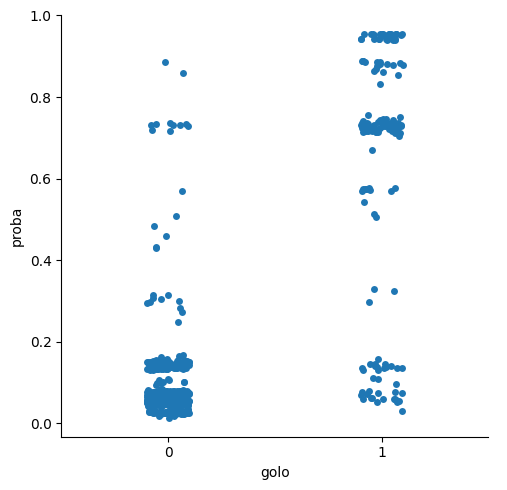

In [ ]:
goal_probability = list()
for res in probability:
  goal_probability.append(res[1])
data = pd.DataFrame(zip(y_test,goal_probability), columns=['golo','proba'])

sns.catplot(x='golo', y='proba',data=data)

In [ ]:
from sklearn.metrics import classification_report

y_pred = grid_search.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       541
           1       0.90      0.75      0.82       156

    accuracy                           0.93       697
   macro avg       0.92      0.86      0.89       697
weighted avg       0.92      0.93      0.92       697



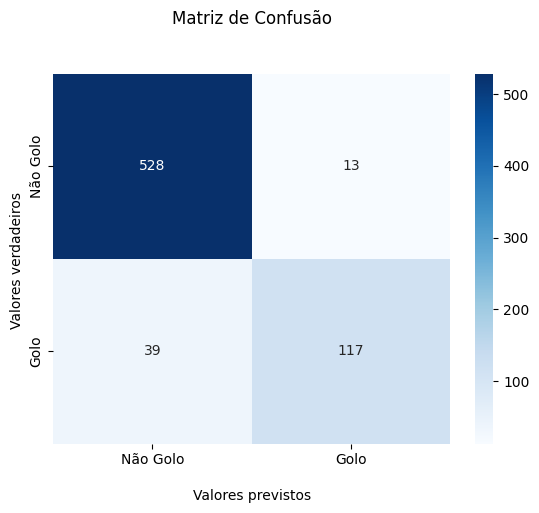

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cf_matrix = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues', fmt='g')

ax.set_title('Matriz de Confusão\n\n');
ax.set_xlabel('\nValores previstos')
ax.set_ylabel('Valores verdadeiros ');

ax.xaxis.set_ticklabels(['Não Golo','Golo'])
ax.yaxis.set_ticklabels(['Não Golo','Golo'])

plt.show()

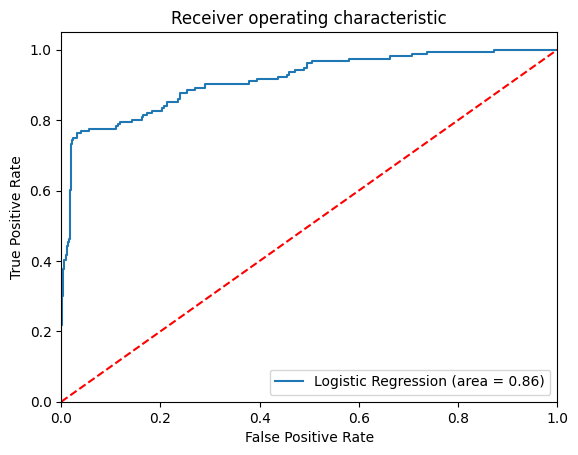

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
logit_roc_auc = roc_auc_score(y_test, grid_search.predict(X_test))
fpr, tpr, thresholds = roc_curve(y_test, grid_search.predict_proba(X_test)[:,1])
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

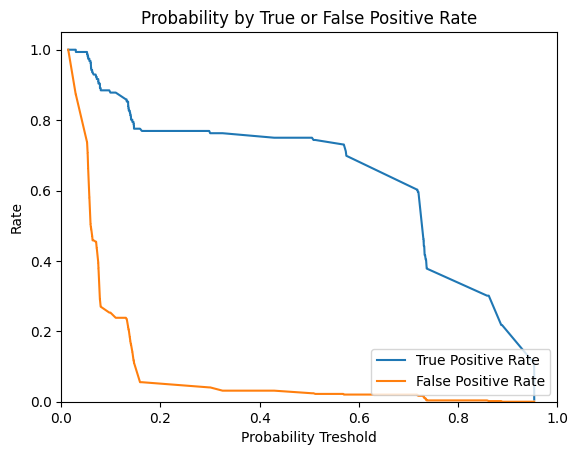

In [ ]:
plt.plot(thresholds, tpr, label='True Positive Rate')
plt.plot(thresholds, fpr, label='False Positive Rate')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Probability Treshold')
plt.ylabel('Rate')
plt.title('Probability by True or False Positive Rate')
plt.legend(loc="lower right")
plt.show()